#### Packages

In [1]:
## Common Packages
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS,
                         summarize)
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statistics


## Packages for this assignment
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score as f1
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from sklearn.metrics.pairwise import euclidean_distances
from ISLP.cluster import compute_linkage
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.exponential_smoothing.ets import ETSModel as ets 
from statsmodels.graphics.tsaplots import plot_acf 
from statsmodels.graphics.tsaplots import plot_pacf 
from statsmodels.tsa.arima.model import ARIMA 
from scipy.stats import kstest
from sklearn.preprocessing import PolynomialFeatures

from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from functools import partial
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns

import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
import random
random.seed(0)

## Common Packages
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS,
                         summarize)
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


## Packages for this assignment
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score as f1
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from sklearn.metrics.pairwise import euclidean_distances
from ISLP.cluster import compute_linkage
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from statsmodels.datasets import get_rdataset


# House Prices - Advanced Regression Techniques  
## Data Import

In [2]:
HousePrice = pd.read_csv('trainReg.csv')
HousePriceTest = pd.read_csv('testReg.csv')
HousePrice[:3]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [3]:
HousePrice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
HousePriceTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

### Missing Values

In [5]:
HousePrice['PoolQC'] = HousePrice['PoolQC'].fillna("N/A")
HousePrice['MiscFeature'] = HousePrice['MiscFeature'].fillna("None")
HousePrice['Alley'] = HousePrice['Alley'].fillna("N/A")
HousePrice['Fence'] = HousePrice['Fence'].fillna("N/A")
HousePrice['FireplaceQu'] = HousePrice['FireplaceQu'].fillna("N/A")
HousePrice['LotFrontage'] = HousePrice['LotFrontage'].fillna(0)
HousePrice['GarageQual'] = HousePrice['GarageQual'].fillna("No Garage")
HousePrice['GarageCond'] = HousePrice['GarageCond'].fillna("No Garage")
HousePrice['GarageFinish'] = HousePrice['GarageFinish'].fillna("No Garage")
HousePrice['GarageType'] = HousePrice['GarageType'].fillna("No Garage")
HousePrice['BsmtFinType1'] = HousePrice['BsmtFinType1'].fillna("No Basement")
HousePrice['BsmtFinType2'] = HousePrice['BsmtFinType2'].fillna("No Basement")
HousePrice['BsmtExposure'] = HousePrice['BsmtExposure'].fillna("No Basement")
HousePrice['BsmtQual'] = HousePrice['BsmtQual'].fillna("No Basement")
HousePrice['BsmtCond'] = HousePrice['BsmtCond'].fillna("No Basement")
HousePrice['MasVnrType'] = HousePrice['MasVnrType'].fillna("None")
HousePrice['MasVnrArea'] = HousePrice['MasVnrArea'].fillna(0)
HousePrice['Electrical'] = HousePrice['Electrical'].fillna("SBrkr")
HousePrice['GarageYrBlt'] = HousePrice['GarageYrBlt'].fillna(0)

#Any other missing values will be replaced with the mean or mode. 
Index = list(HousePrice.select_dtypes(include=['number']))

Index.remove('Id')
Index.remove('SalePrice')
for X in Index:
    HousePrice[X] = HousePrice[X].fillna(np.mean(HousePrice[X]))

IndexCat = list(HousePrice.select_dtypes(include=['object']))
for X in IndexCat:
    HousePrice[X] = HousePrice[X].fillna(statistics.mode(HousePrice[X]))



In [6]:
HousePriceTest['PoolQC'] = HousePriceTest['PoolQC'].fillna("N/A")
HousePriceTest['MiscFeature'] = HousePriceTest['MiscFeature'].fillna("None")
HousePriceTest['Alley'] = HousePriceTest['Alley'].fillna("N/A")
HousePriceTest['Fence'] = HousePriceTest['Fence'].fillna("N/A")
HousePriceTest['FireplaceQu'] = HousePriceTest['FireplaceQu'].fillna("N/A")
HousePriceTest['LotFrontage'] = HousePriceTest['LotFrontage'].fillna(0)
HousePriceTest['GarageQual'] = HousePriceTest['GarageQual'].fillna("No Garage")
HousePriceTest['GarageCond'] = HousePriceTest['GarageCond'].fillna("No Garage")
HousePriceTest['GarageFinish'] = HousePriceTest['GarageFinish'].fillna("No Garage")
HousePriceTest['GarageType'] = HousePriceTest['GarageType'].fillna("No Garage")
HousePriceTest['BsmtFinType1'] = HousePriceTest['BsmtFinType1'].fillna("No Basement")
HousePriceTest['BsmtFinType2'] = HousePriceTest['BsmtFinType2'].fillna("No Basement")
HousePriceTest['BsmtExposure'] = HousePriceTest['BsmtExposure'].fillna("No Basement")
HousePriceTest['BsmtQual'] = HousePriceTest['BsmtQual'].fillna("No Basement")
HousePriceTest['BsmtCond'] = HousePriceTest['BsmtCond'].fillna("No Basement")
HousePriceTest['MasVnrType'] = HousePriceTest['MasVnrType'].fillna("None")
HousePriceTest['MasVnrArea'] = HousePriceTest['MasVnrArea'].fillna(0)
HousePriceTest['Electrical'] = HousePriceTest['Electrical'].fillna("SBrkr")
HousePriceTest['GarageYrBlt'] = HousePriceTest['GarageYrBlt'].fillna(0)

#Any other missing values will be replaced with the mean or mode. 
Index = list(HousePriceTest.select_dtypes(include=['number']))

Index.remove('Id')
for X in Index:
    HousePriceTest[X] = HousePriceTest[X].fillna(np.mean(HousePriceTest[X]))

IndexCat = list(HousePriceTest.select_dtypes(include=['object']))
for X in IndexCat:
    HousePriceTest[X] = HousePriceTest[X].fillna(statistics.mode(HousePriceTest[X]))



In [7]:
HousePrice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
HousePriceTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1459 non-null   object 
 3   LotFrontage    1459 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          1459 non-null   object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1459 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

### Normality of Sale Price

Text(0.5, 1.0, 'Sale Price')

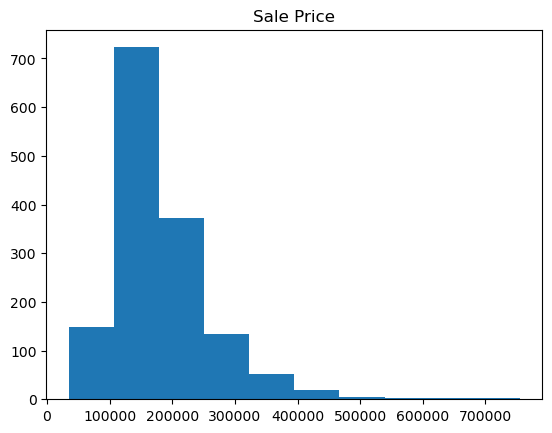

In [9]:
plt.hist(HousePrice['SalePrice'])
plt.title('Sale Price')

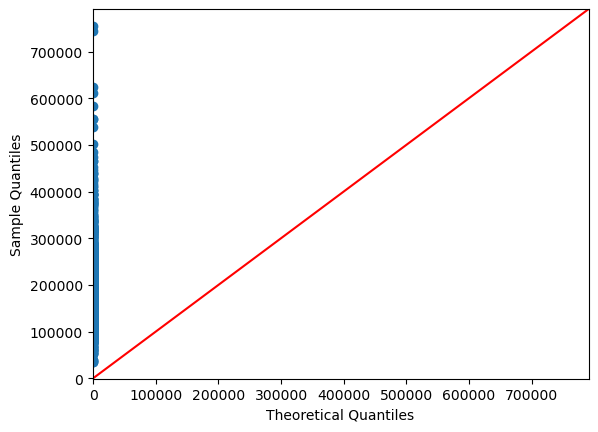

In [10]:
sm.qqplot(HousePrice['SalePrice'], line ='45') 
plt.show()

In [11]:
kstest(HousePrice['SalePrice'], 'norm')

KstestResult(statistic=1.0, pvalue=0.0, statistic_location=34900, statistic_sign=-1)

## Transform Sale Price

In [12]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
data = HousePrice['SalePrice'].to_numpy().reshape(-1, 1)
pt.fit(data)
data2 = pt.transform(data)
print(pt.lambdas_)

HousePrice['T_SalePrice'] = data2

[-0.0769321]


Text(0.5, 1.0, 'Transformed Sale Price')

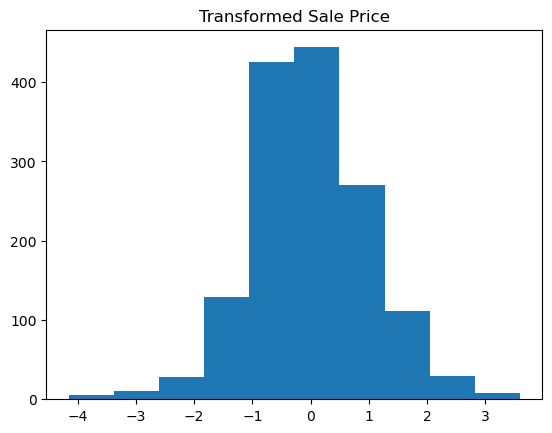

In [13]:
plt.hist(HousePrice['T_SalePrice'])
plt.title('Transformed Sale Price')


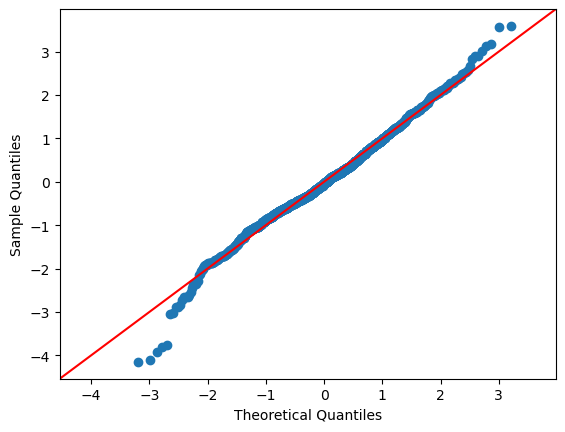

In [14]:
sm.qqplot(HousePrice['T_SalePrice'], line ='45') 
plt.show()

In [15]:
kstest(HousePrice['T_SalePrice'], 'norm')

KstestResult(statistic=0.03557785667352542, pvalue=0.048453084810326064, statistic_location=0.3414038874491596, statistic_sign=1)

### Visualize Numeric Features with Sale Price

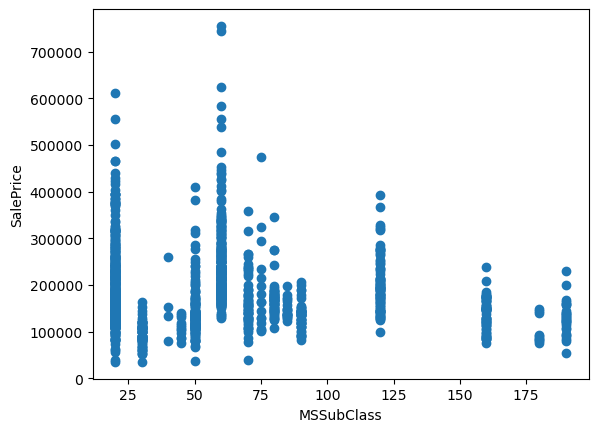

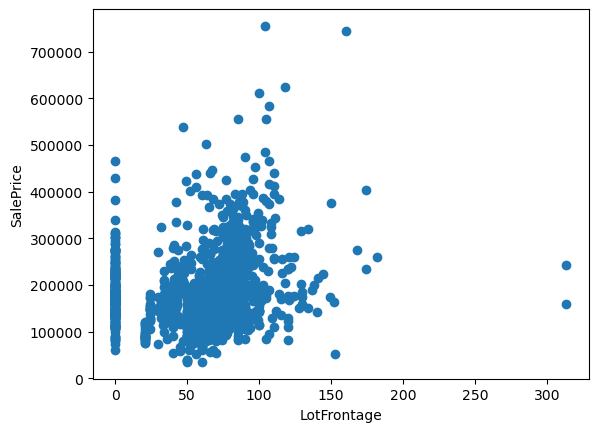

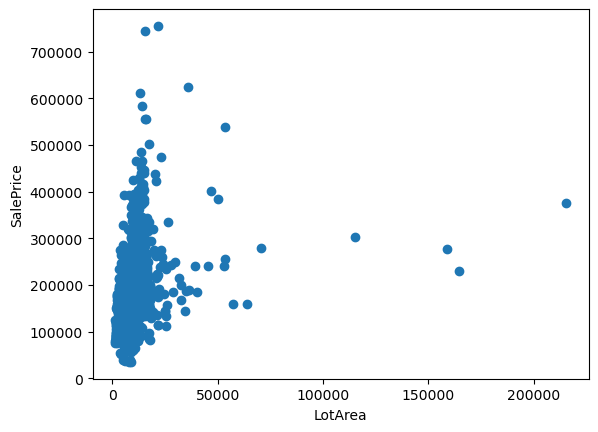

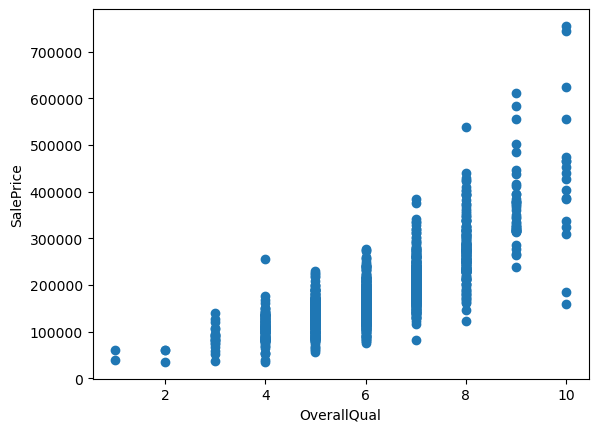

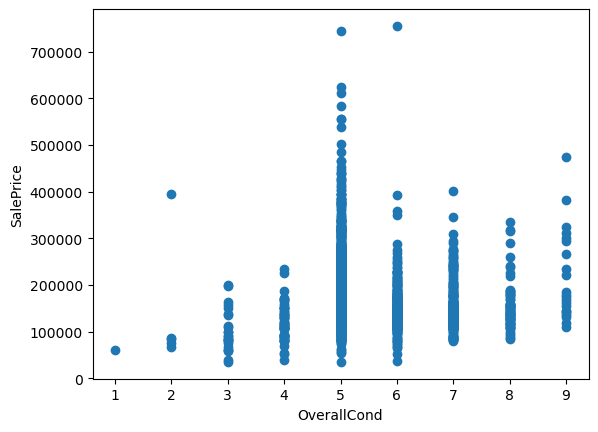

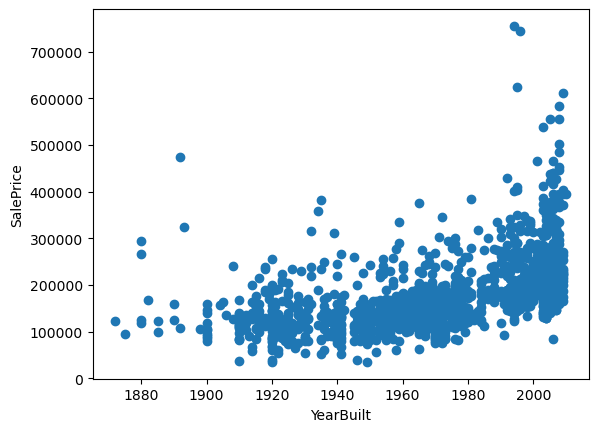

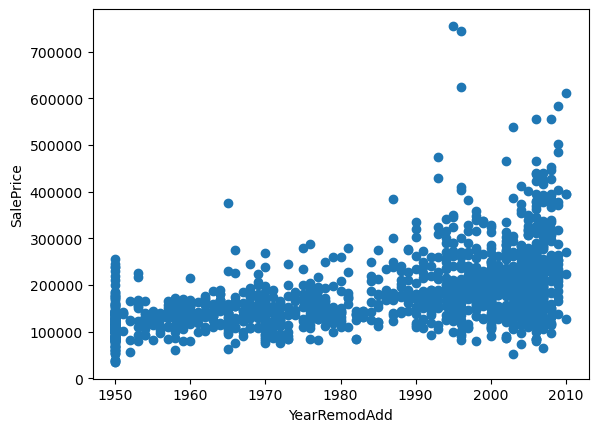

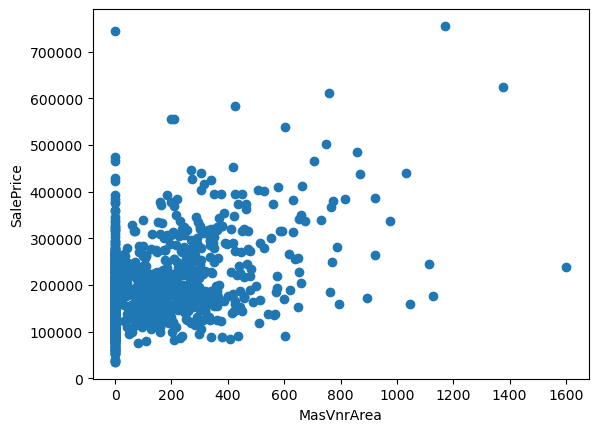

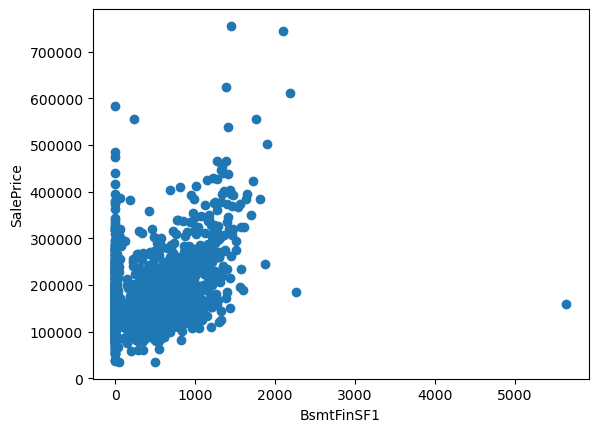

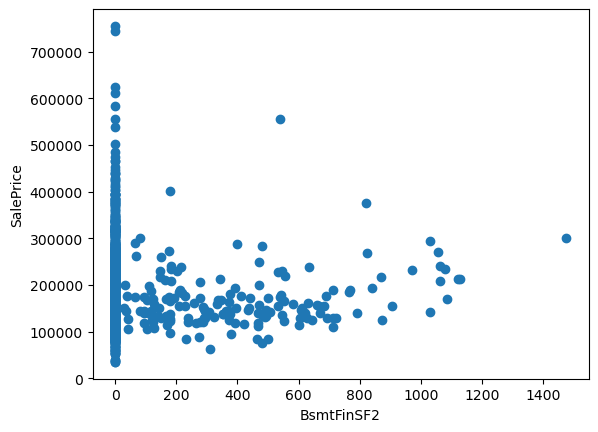

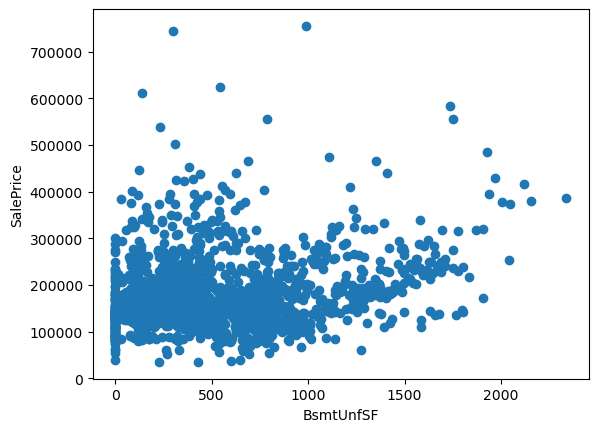

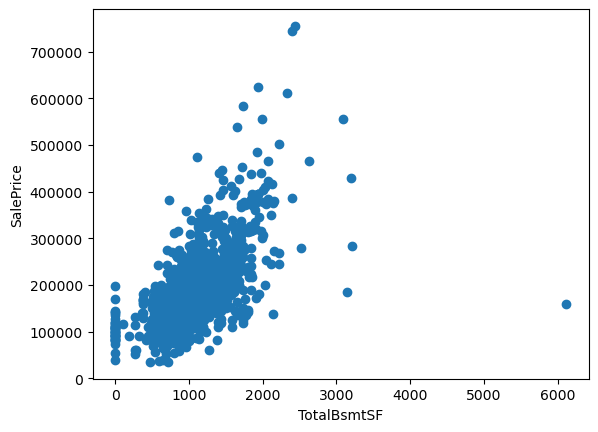

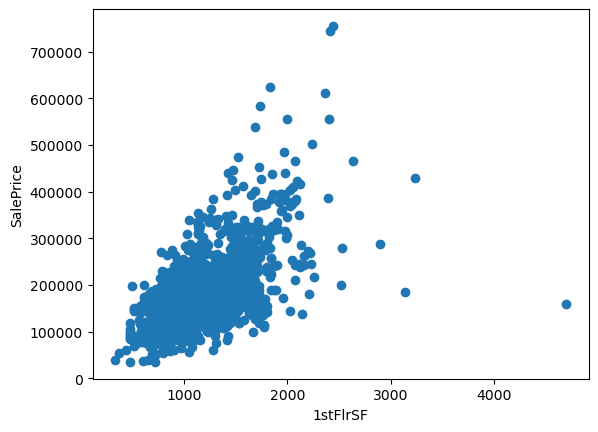

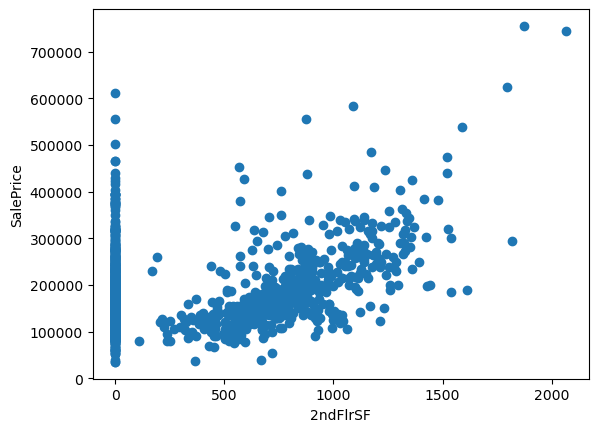

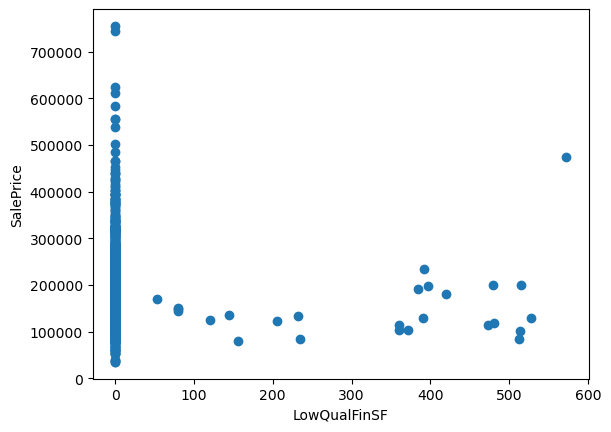

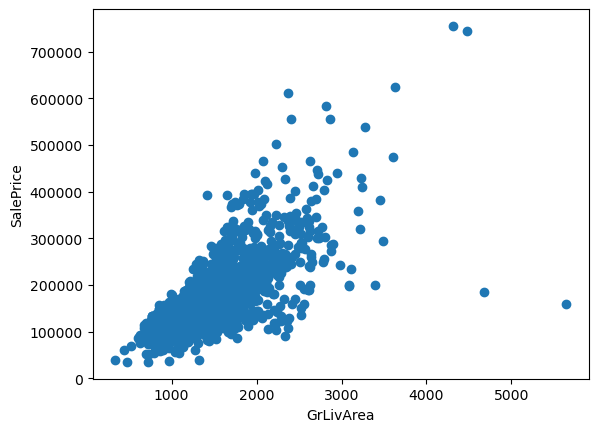

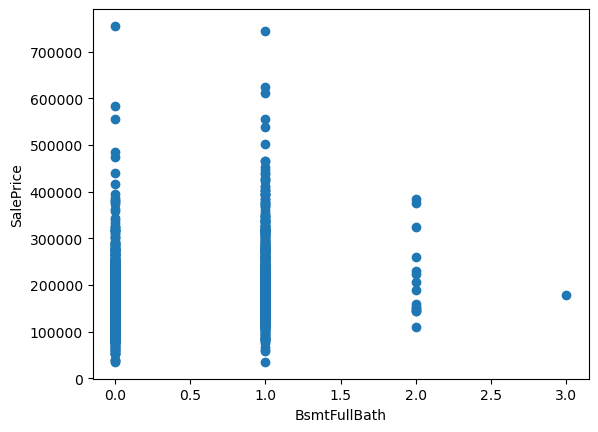

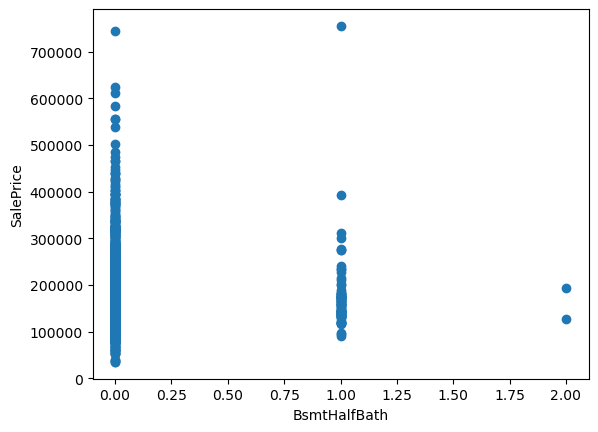

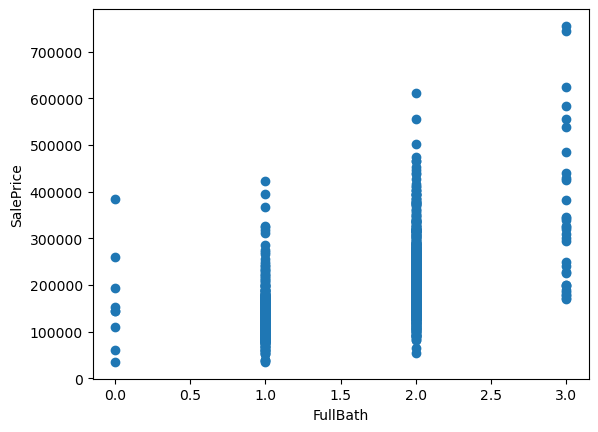

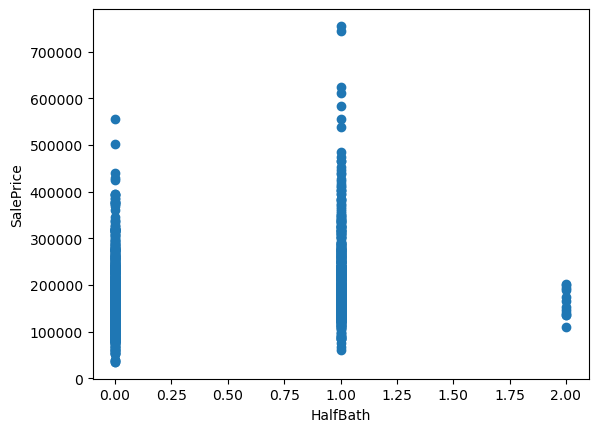

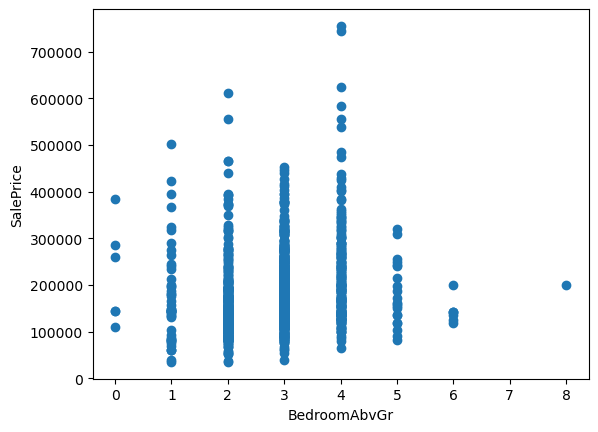

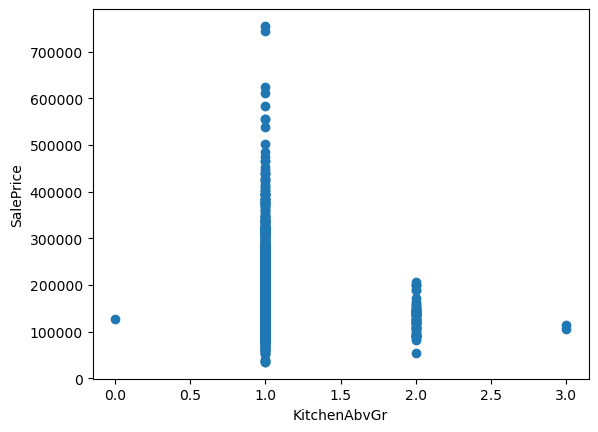

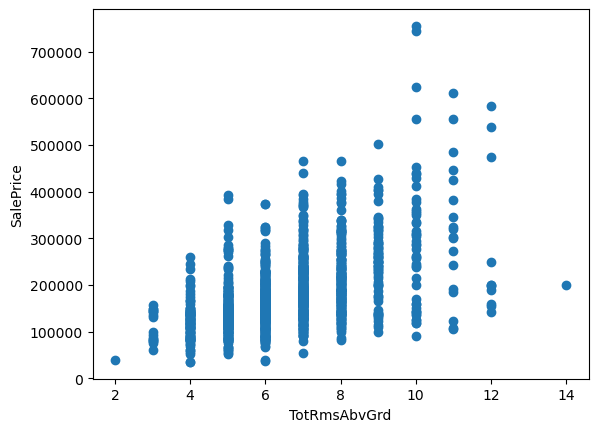

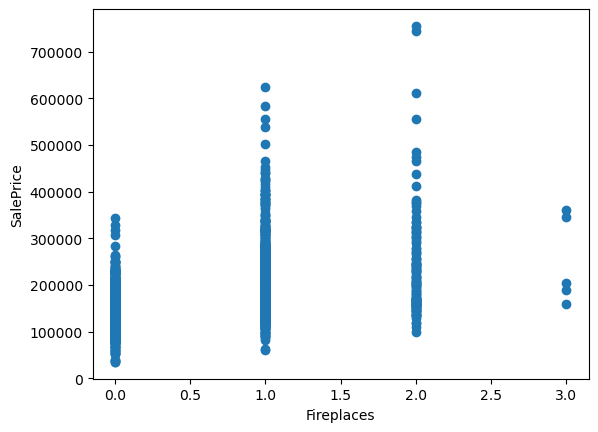

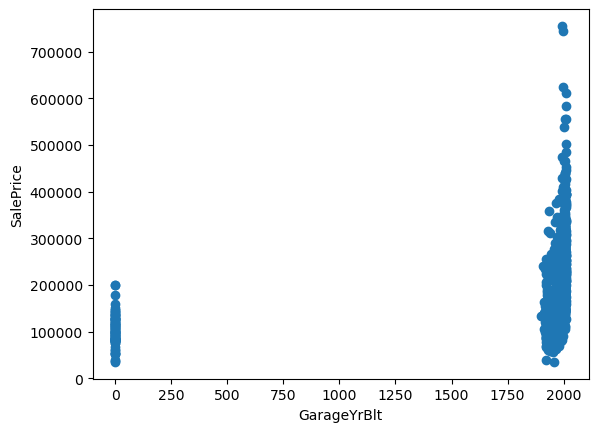

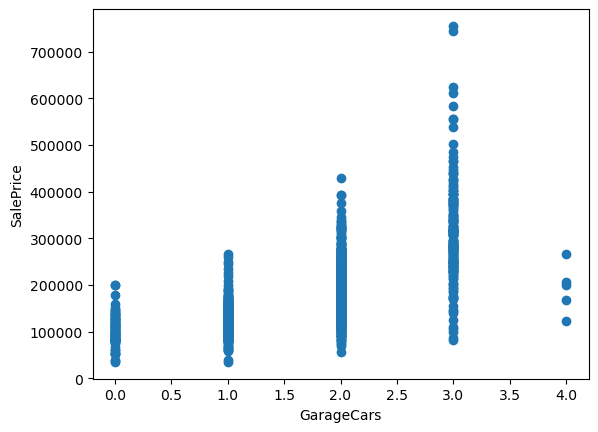

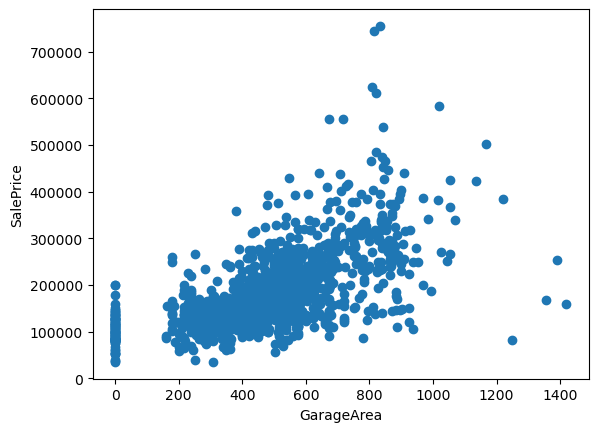

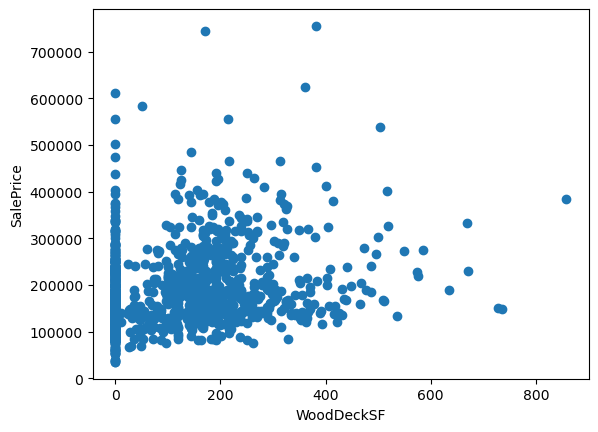

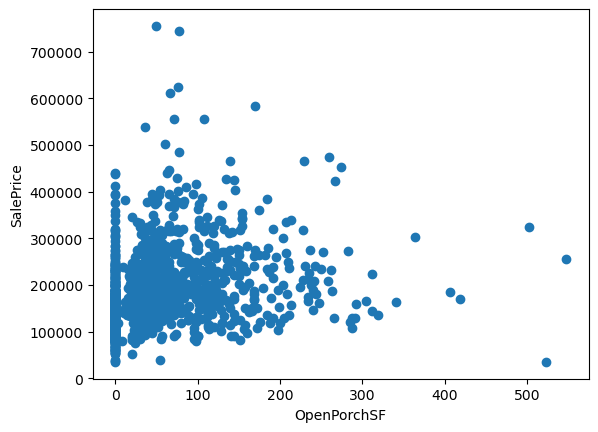

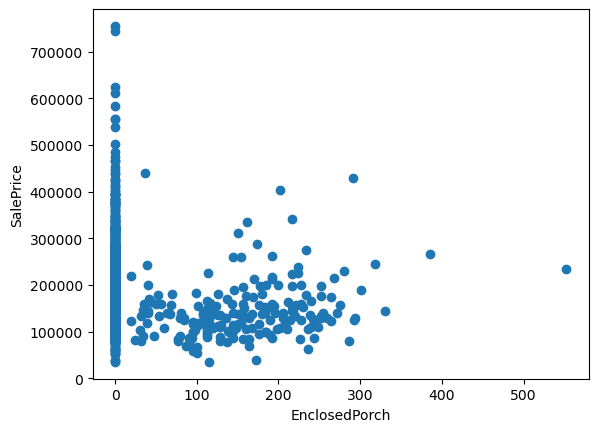

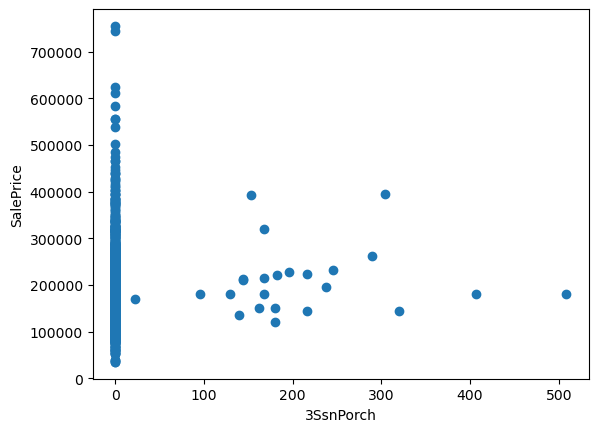

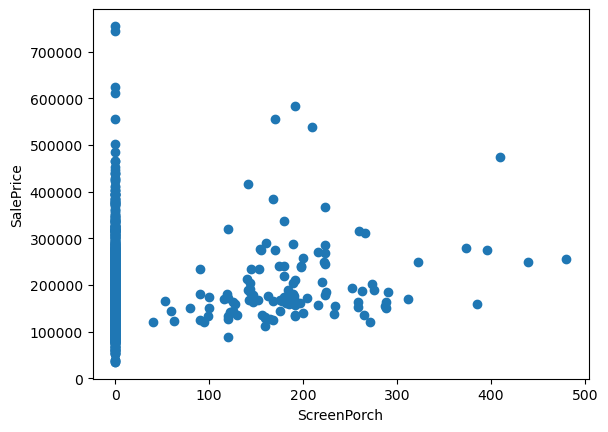

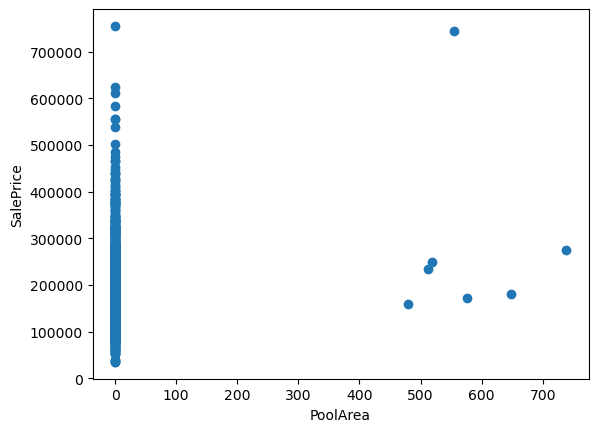

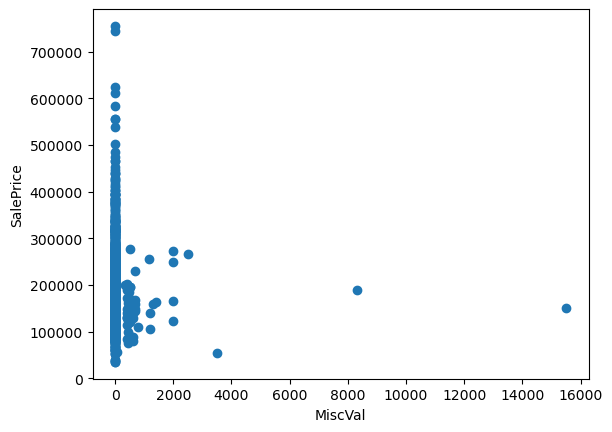

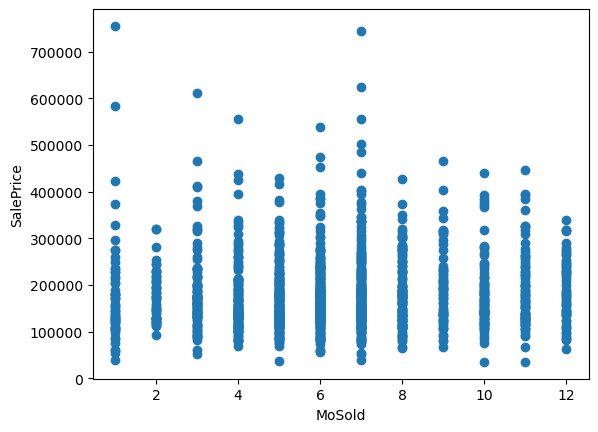

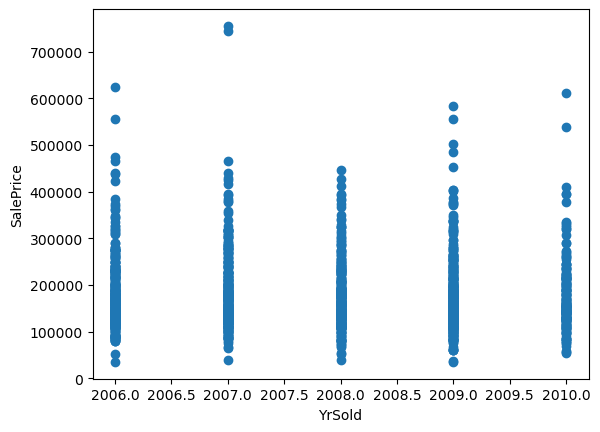

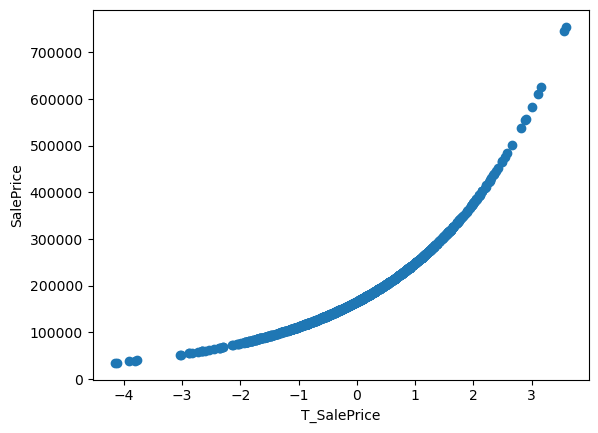

In [16]:
Index = list(HousePrice.select_dtypes(include=['number']))

Index.remove('Id')
Index.remove('SalePrice')
for X in Index:
        plt.scatter(HousePrice[X], HousePrice['SalePrice'])
        plt.xlabel(X)
        plt.ylabel("SalePrice")
        plt.show()

### Visualize Numeric Features with Transformed Sale Price

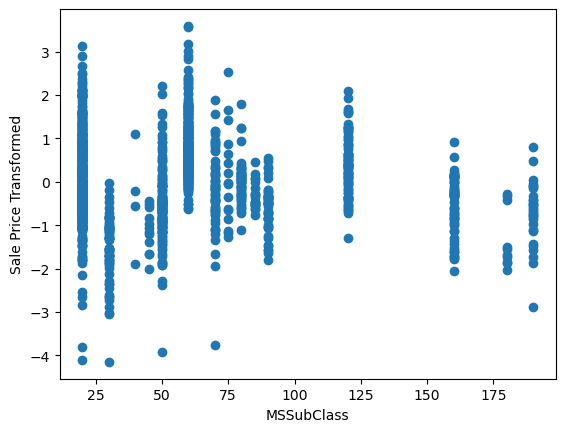

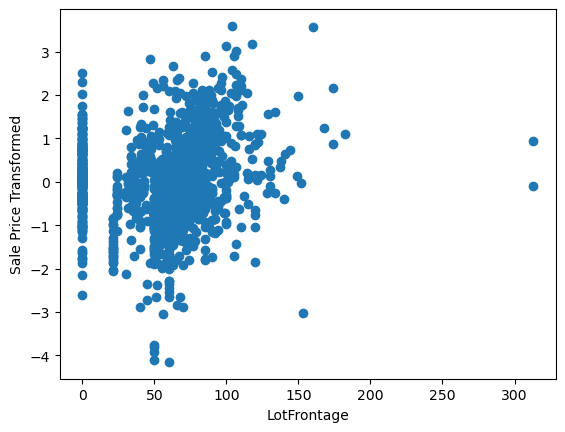

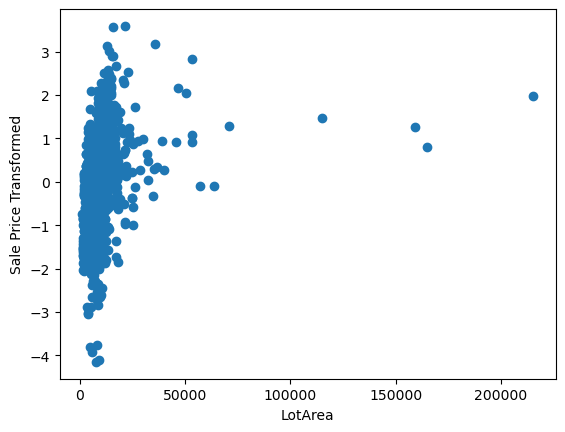

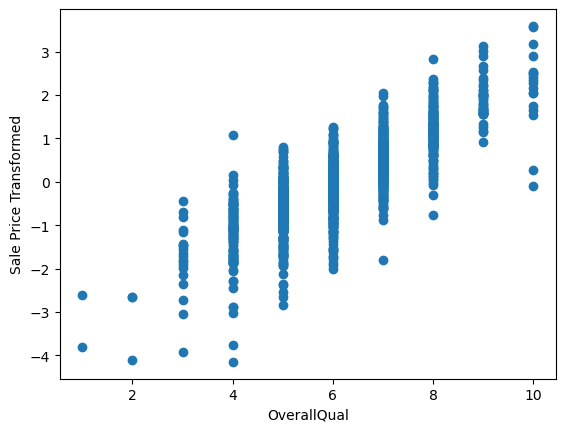

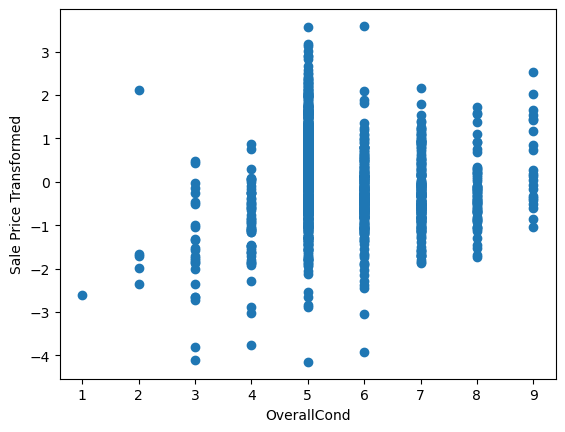

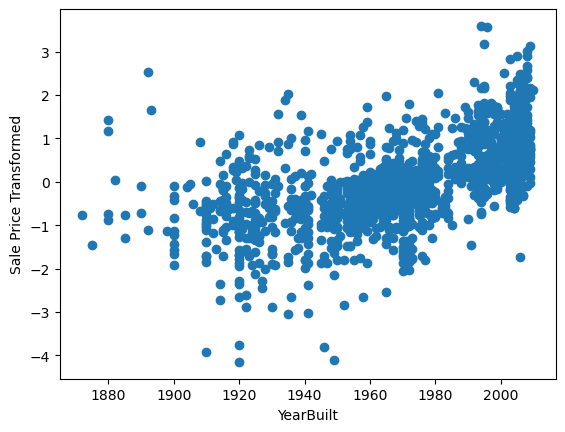

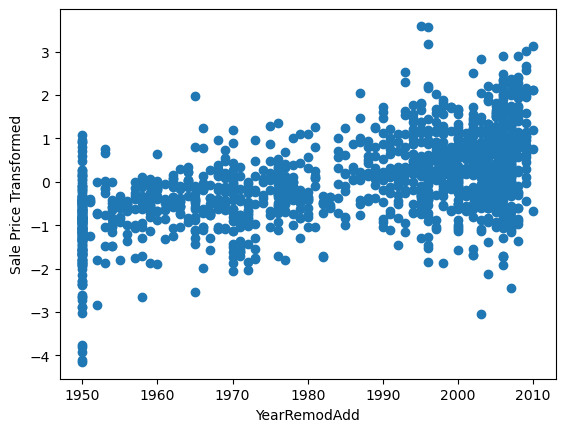

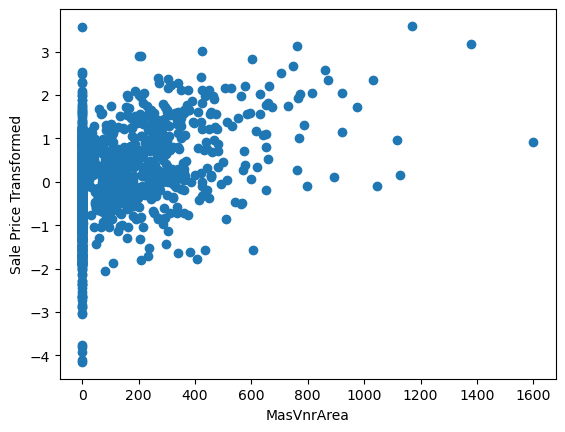

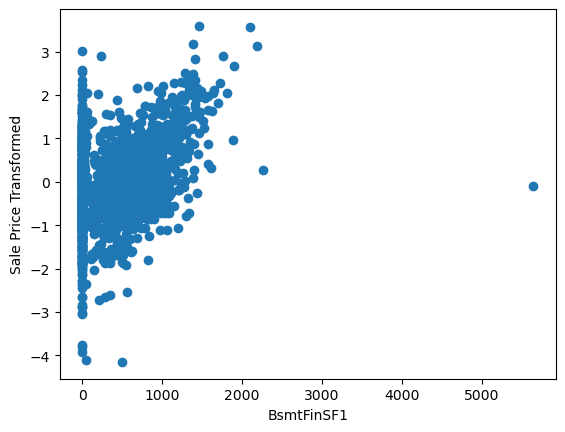

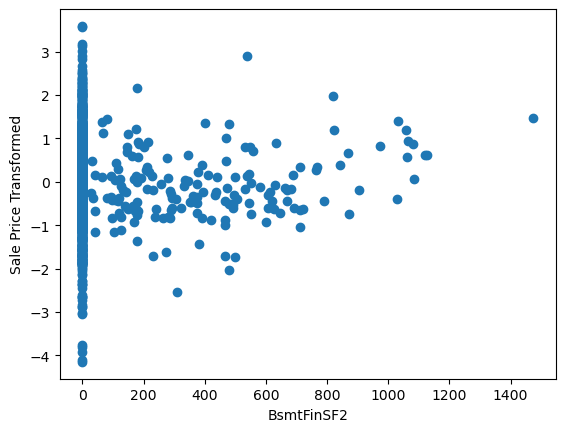

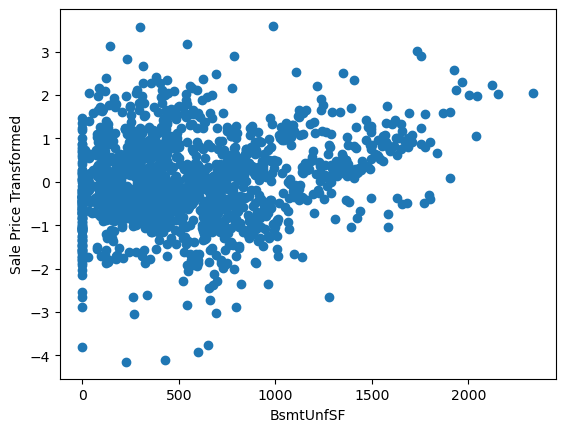

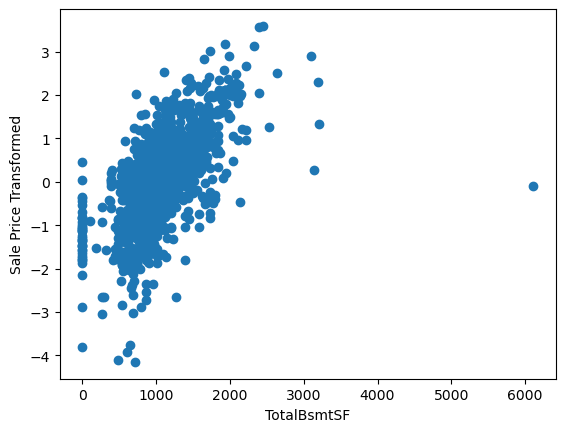

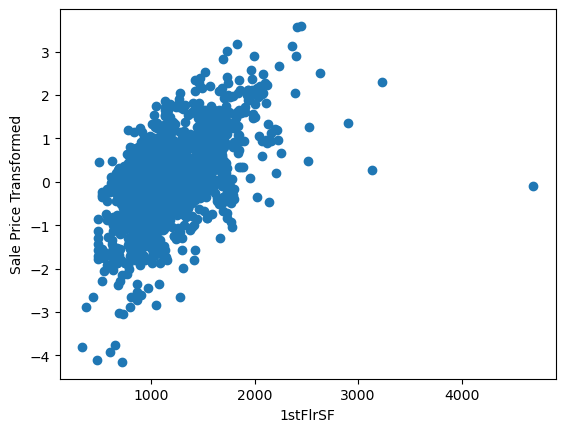

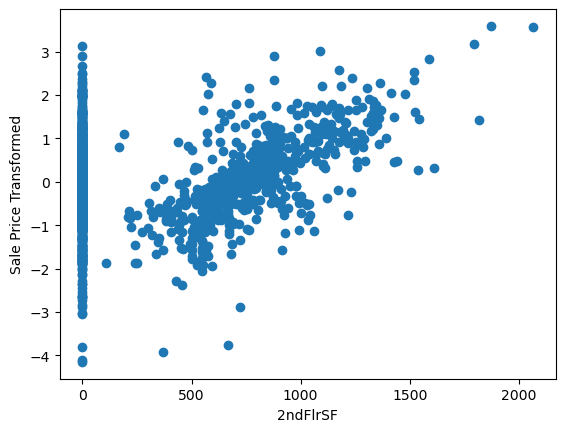

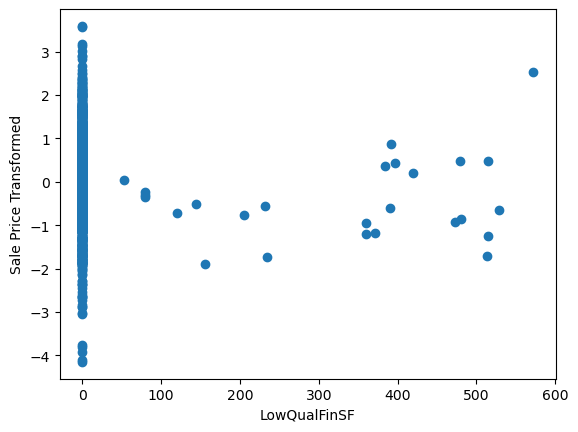

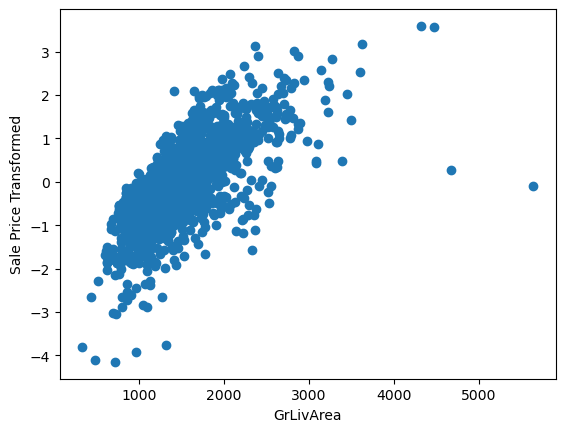

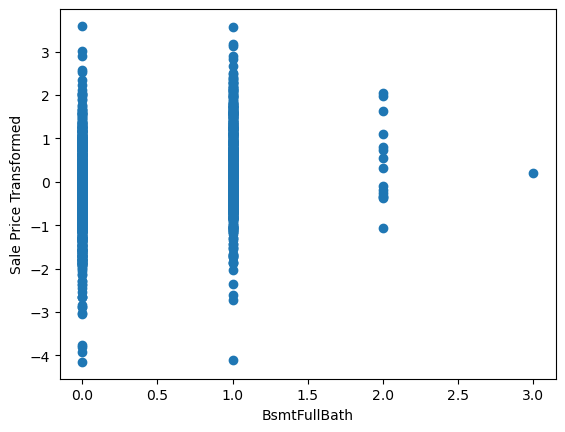

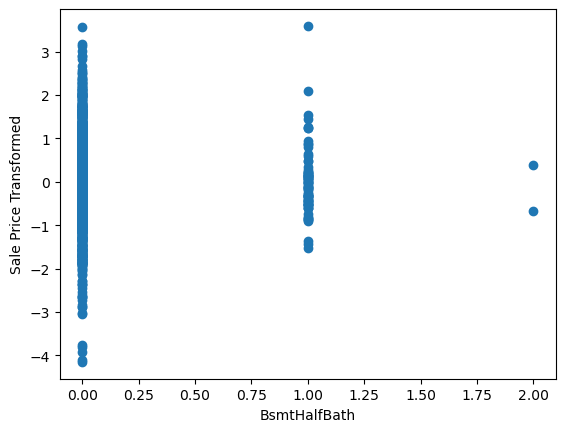

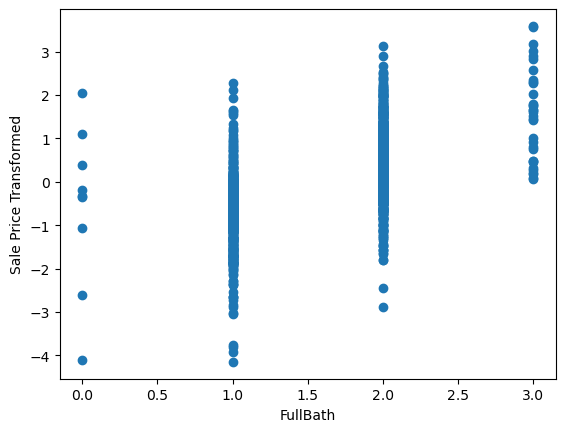

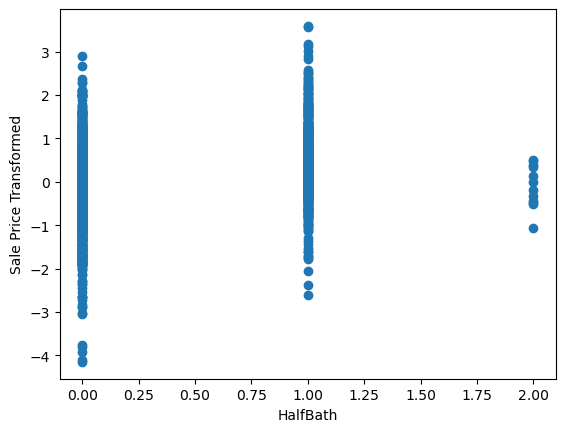

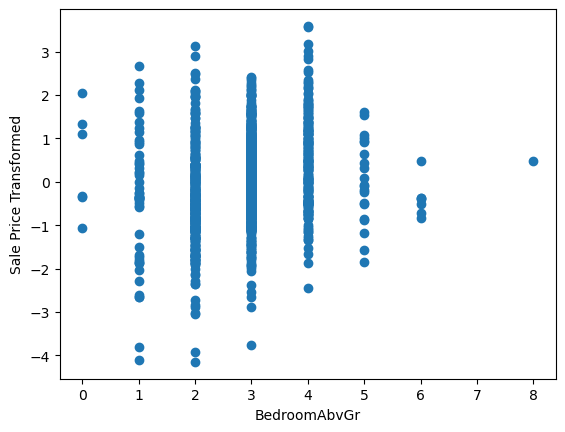

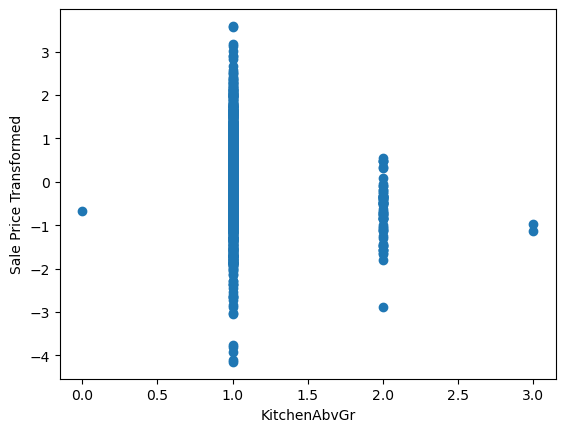

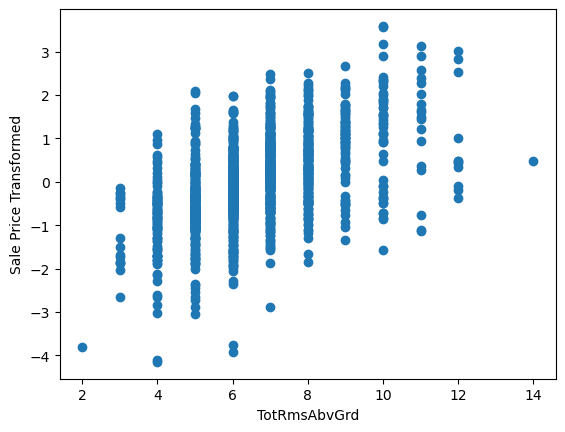

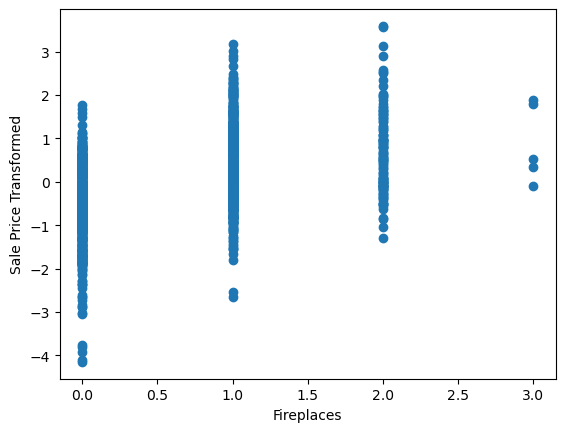

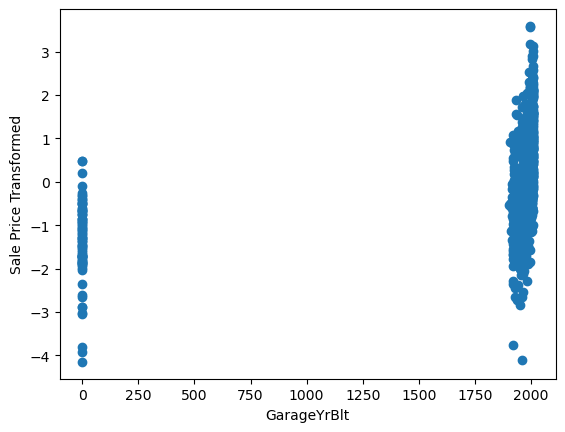

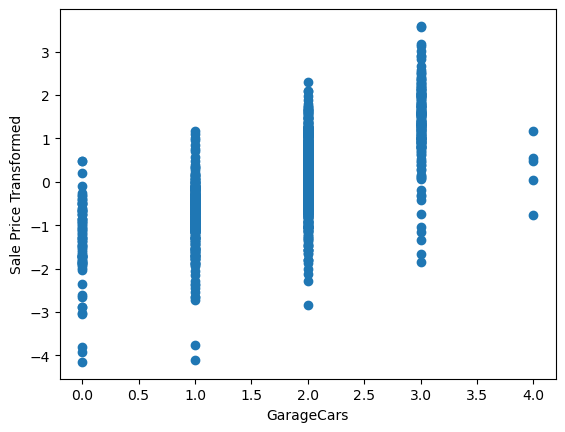

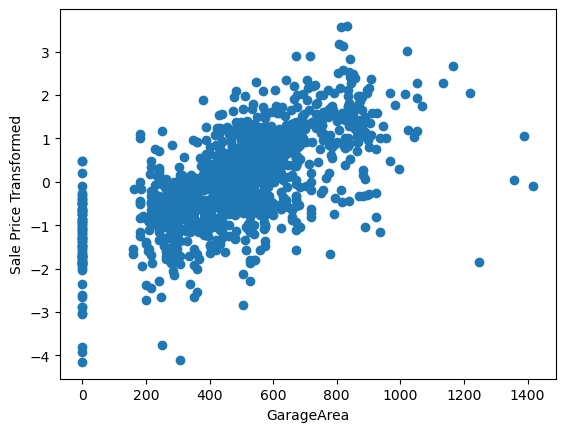

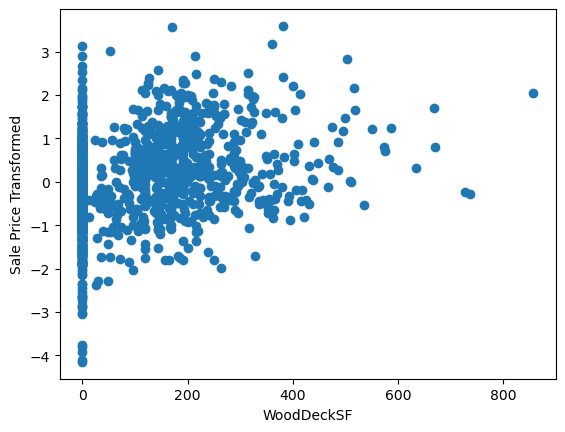

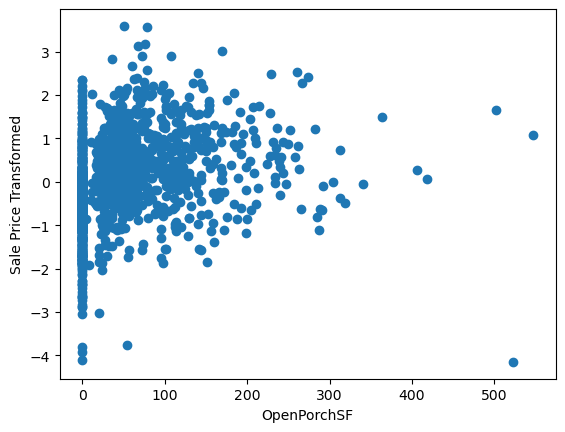

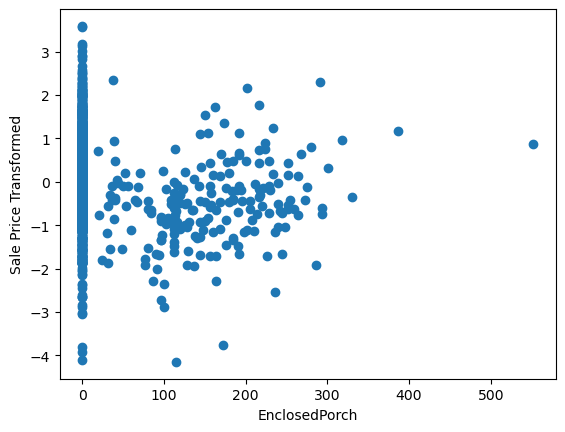

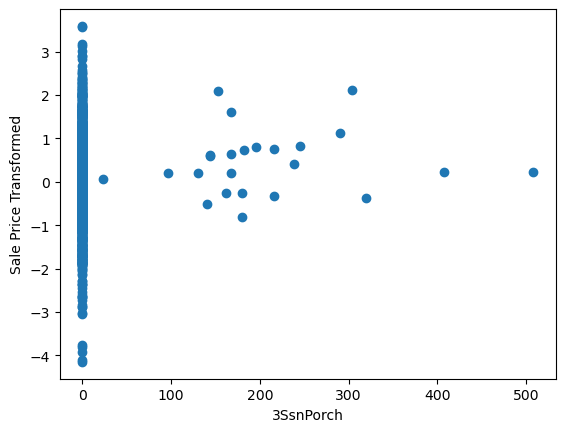

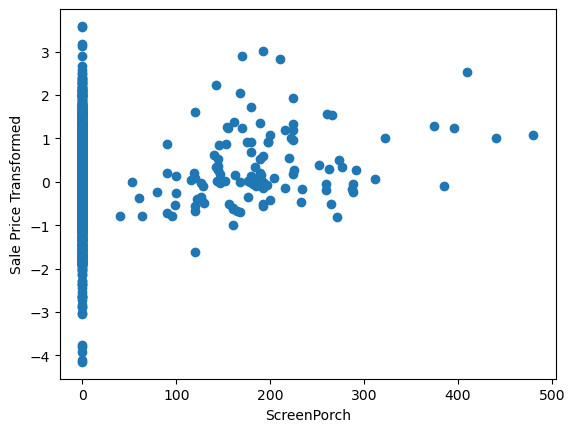

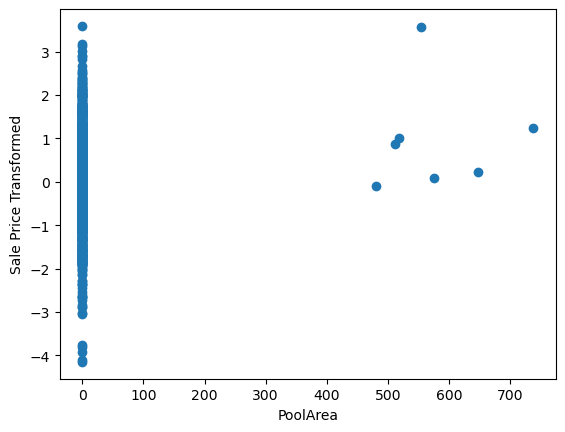

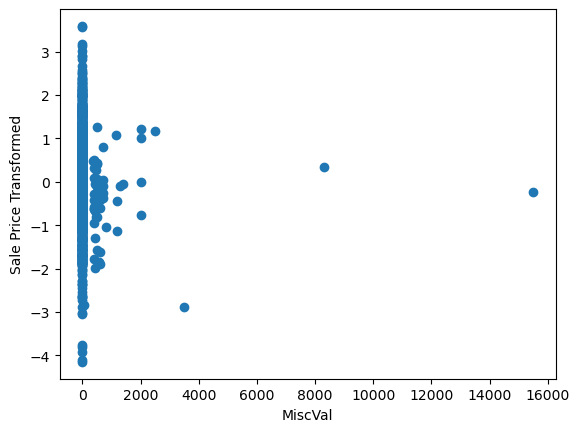

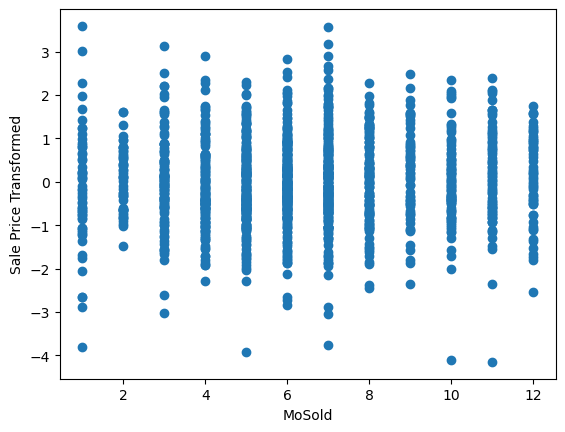

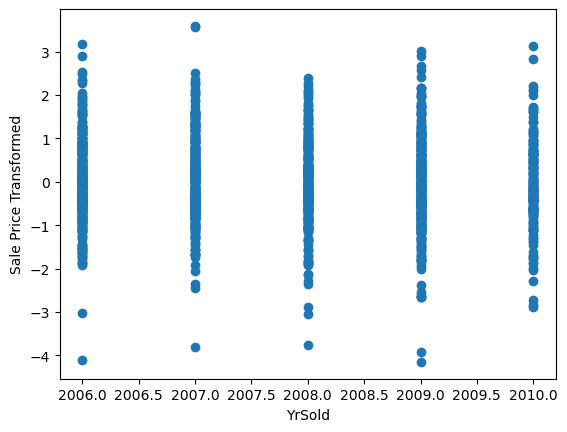

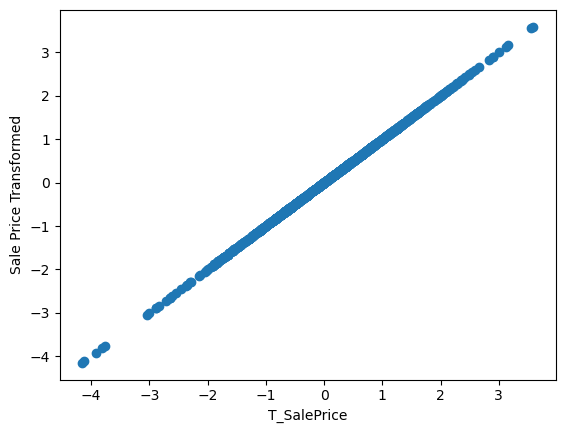

In [17]:
Index = list(HousePrice.select_dtypes(include=['number']))

Index.remove('Id')
Index.remove('SalePrice')
for X in Index:
        plt.scatter(HousePrice[X], HousePrice['T_SalePrice'])
        plt.xlabel(X)
        plt.ylabel("Sale Price Transformed")
        plt.show()

### Visualize Non-numeric Features with Transformed Sale Price

In [18]:
IndexCat = list(HousePrice.select_dtypes(include=['object']))
IndexCat

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

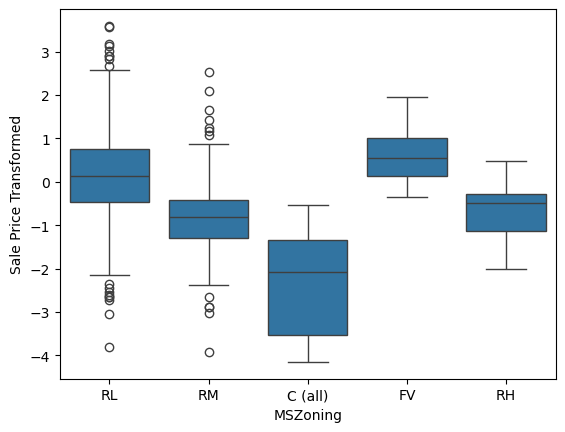

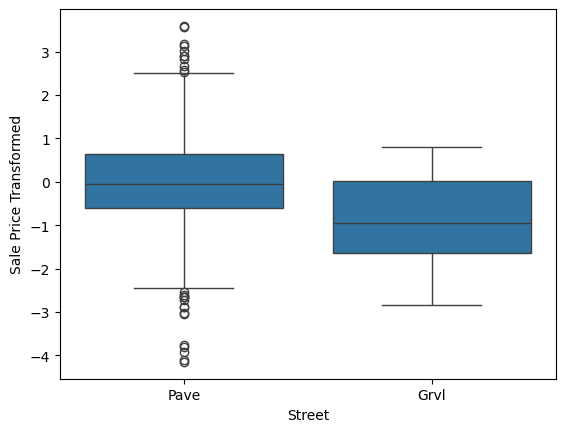

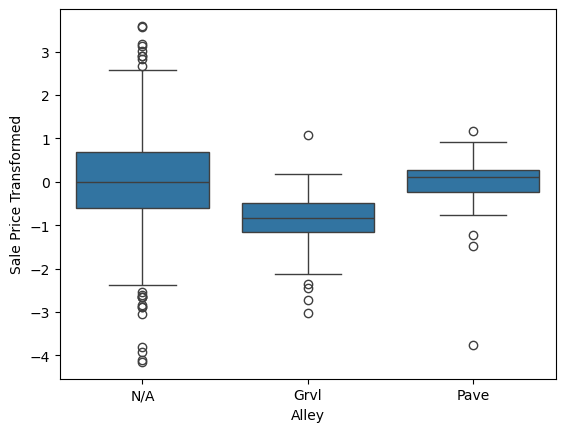

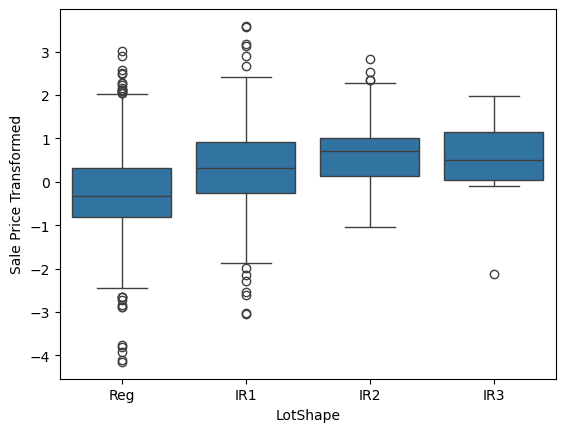

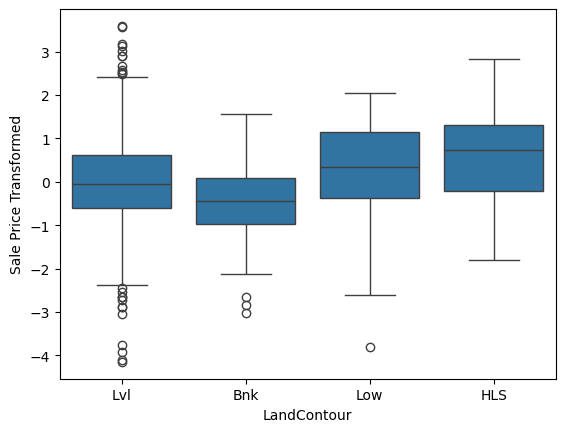

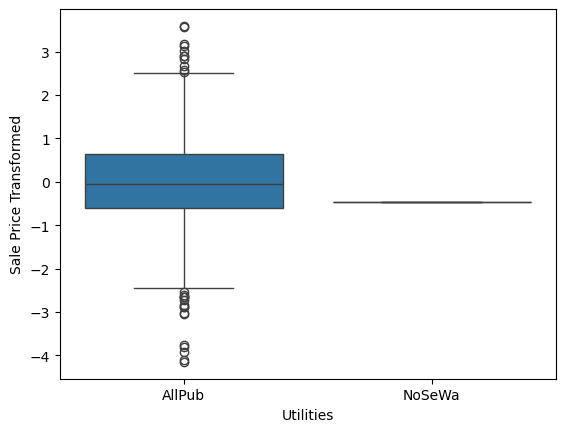

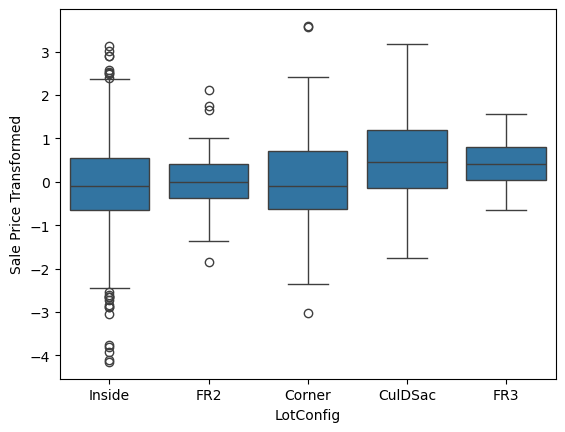

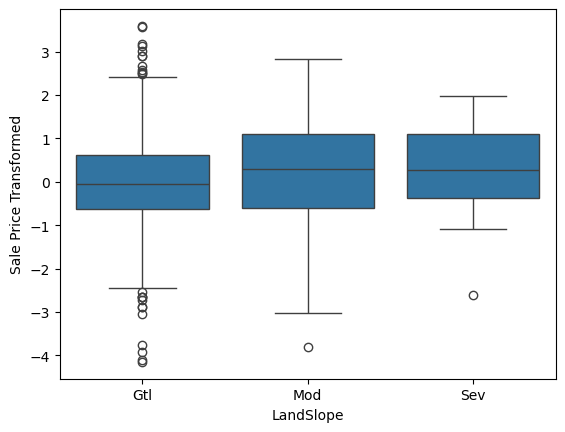

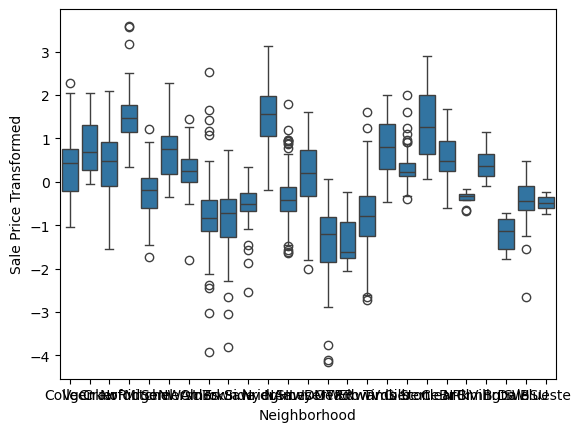

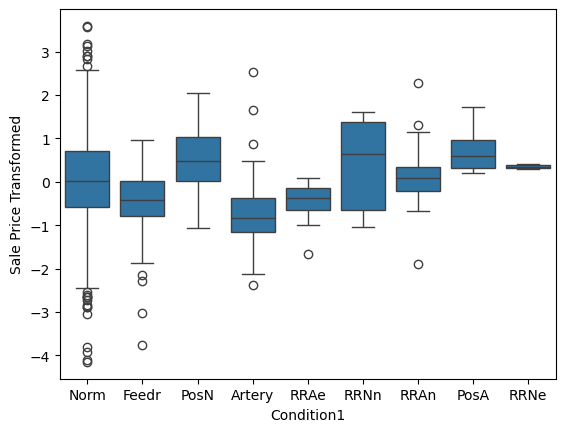

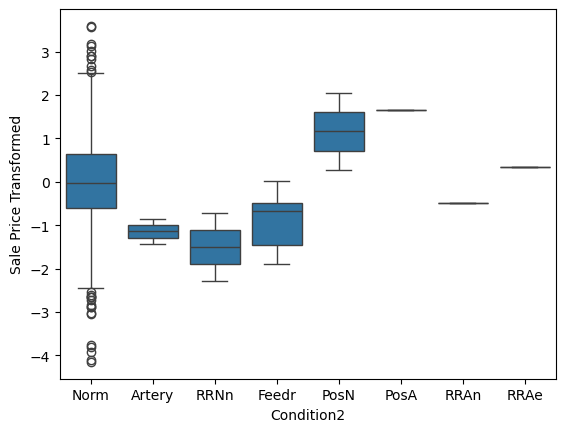

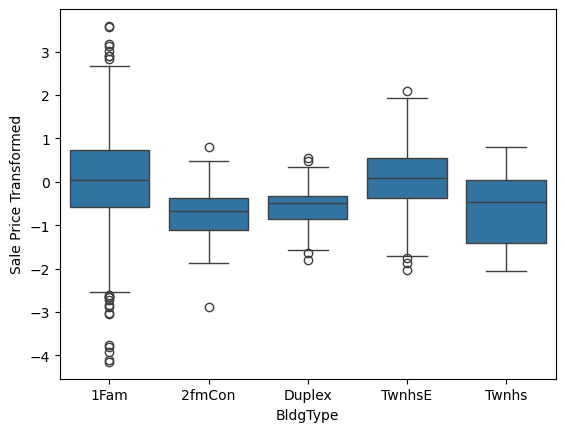

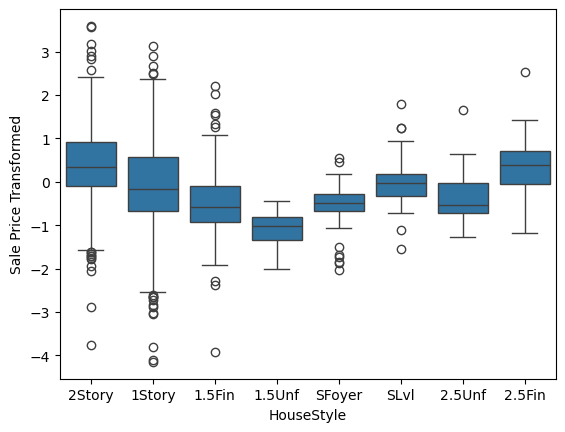

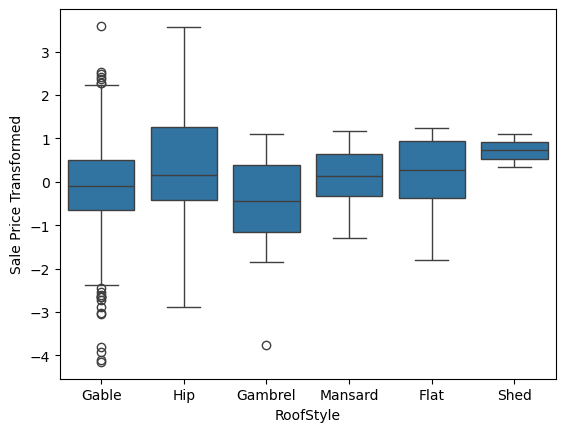

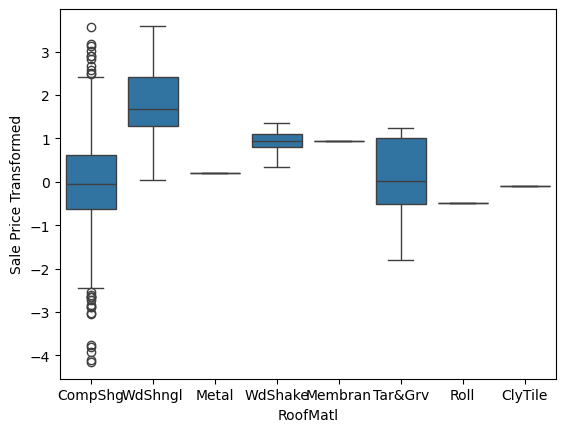

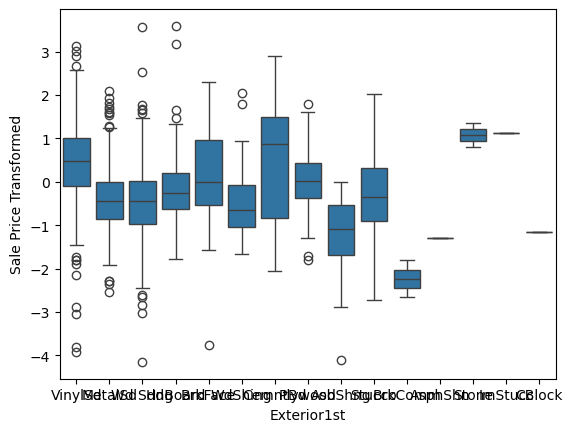

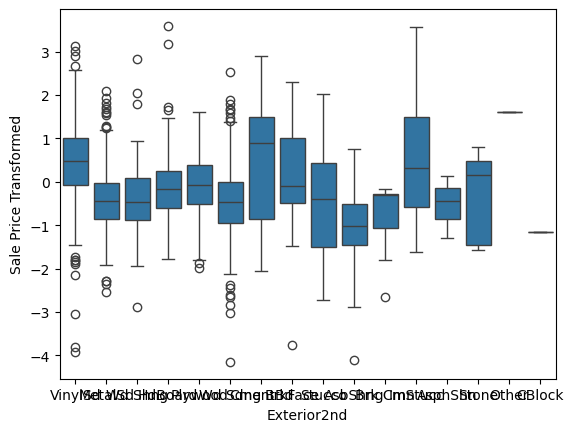

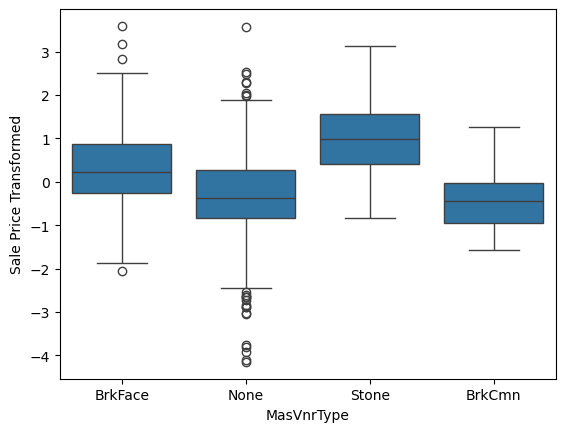

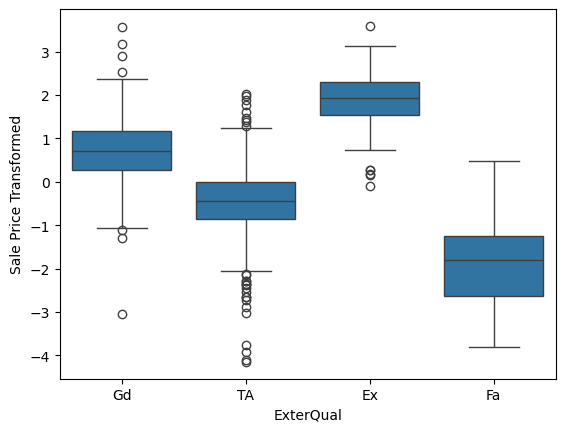

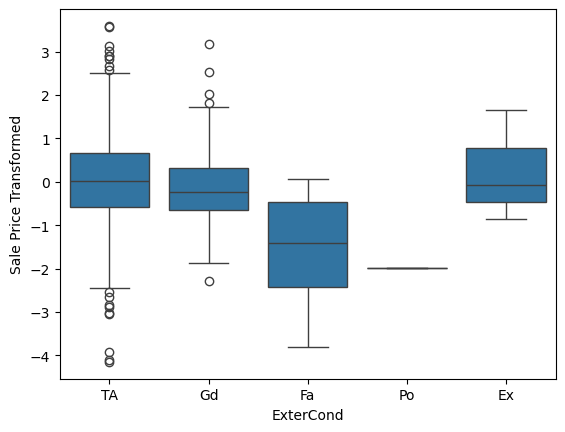

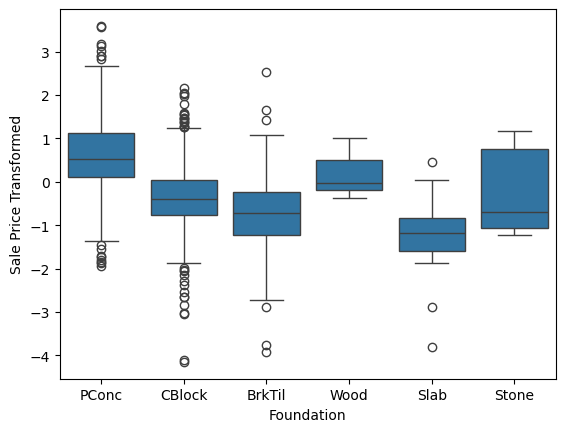

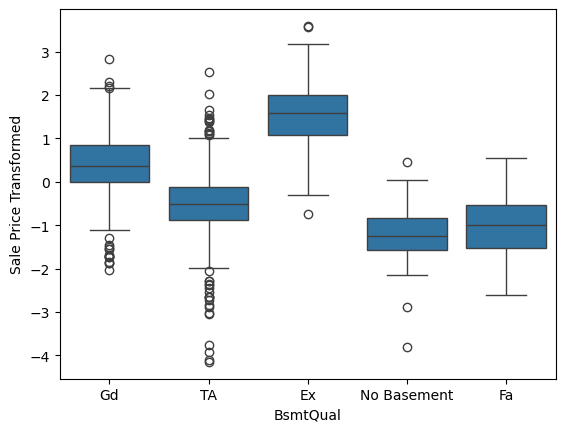

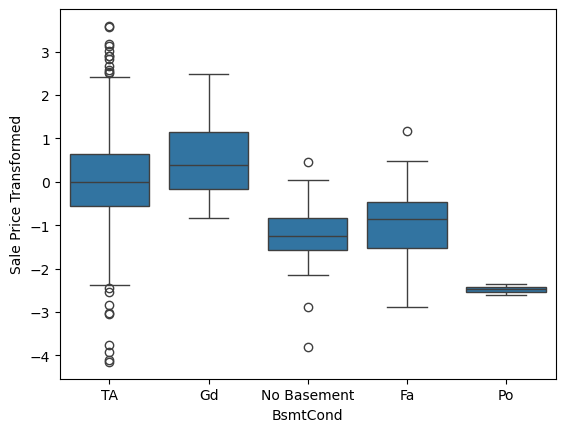

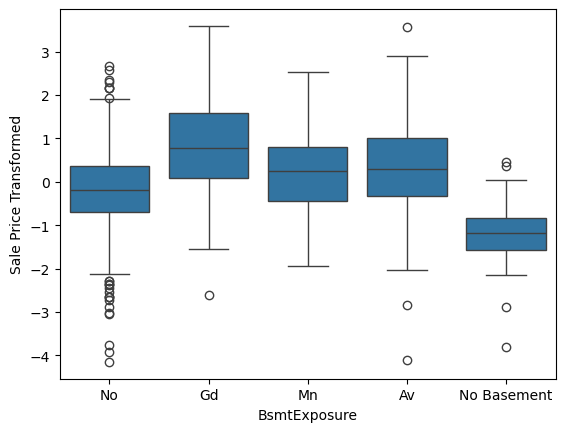

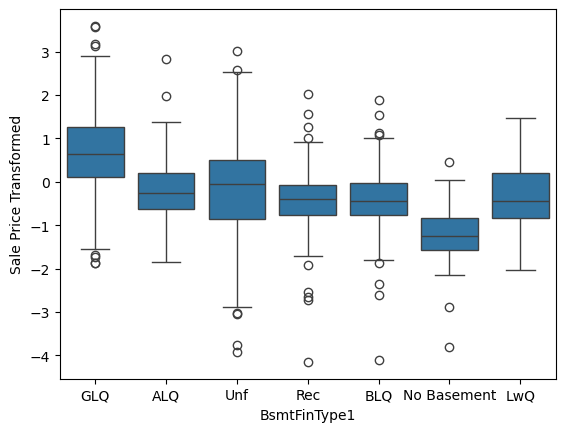

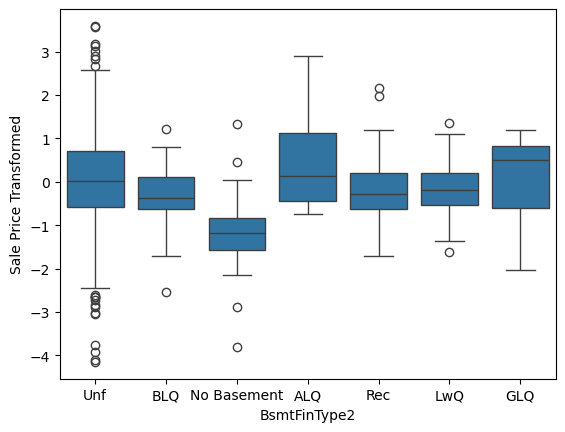

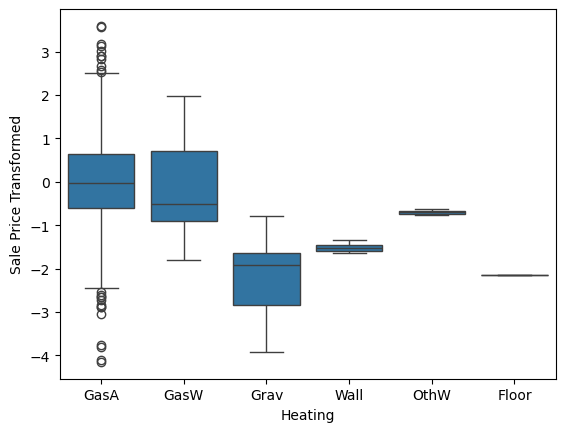

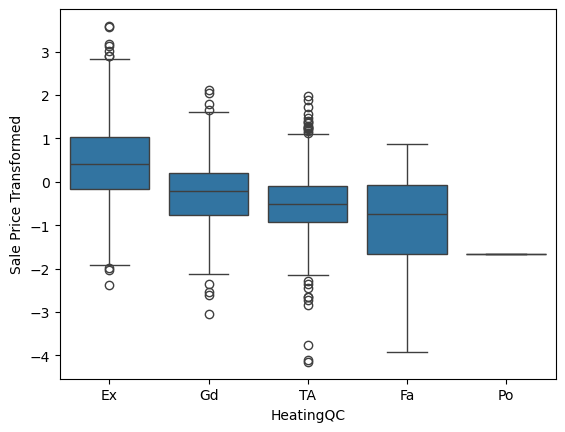

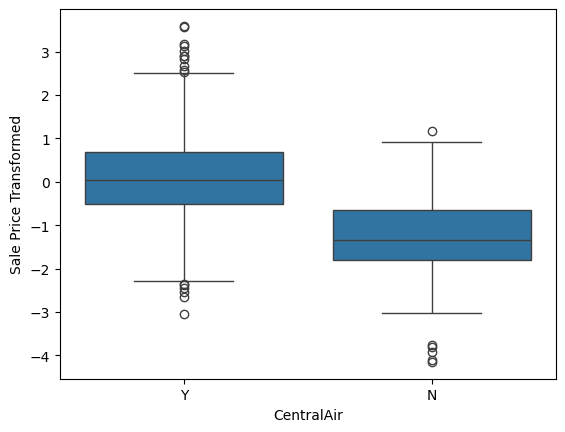

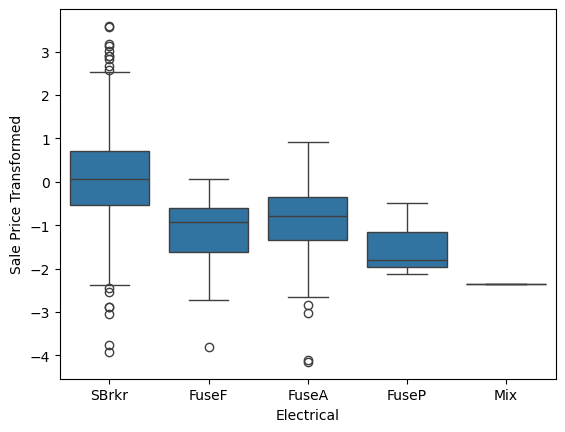

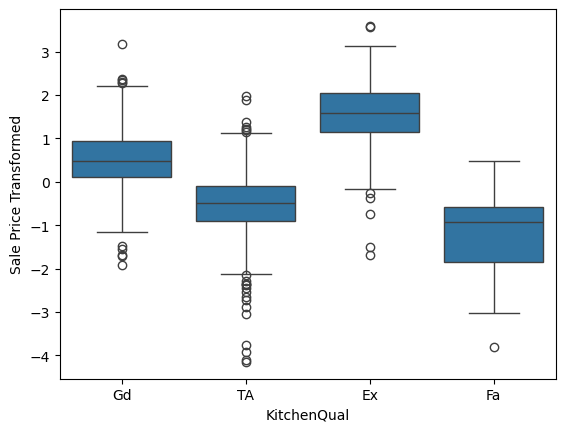

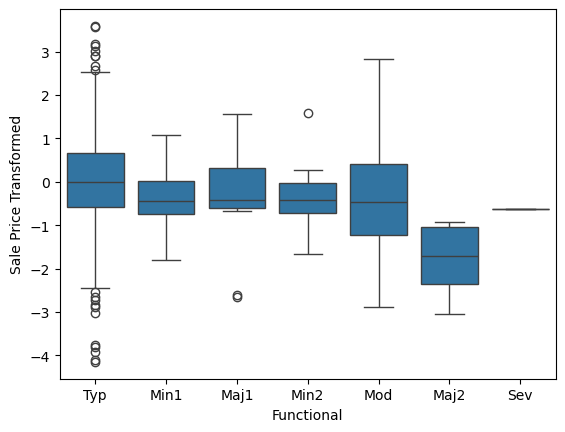

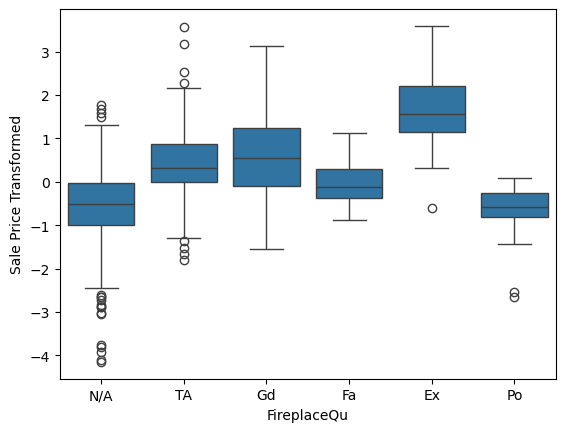

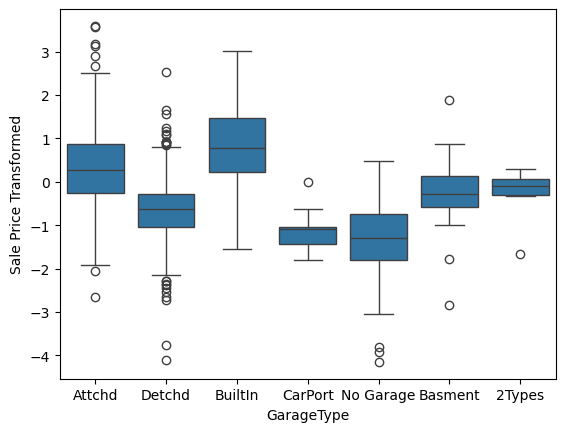

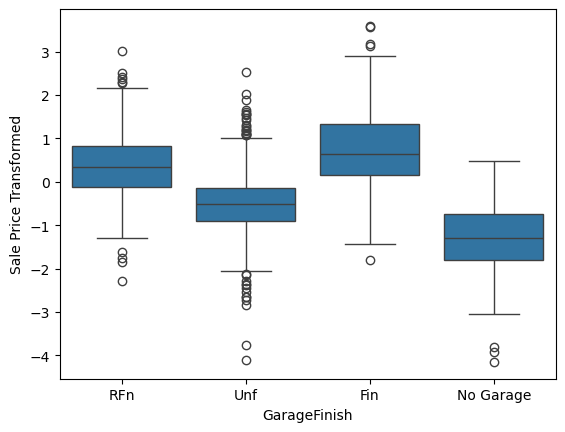

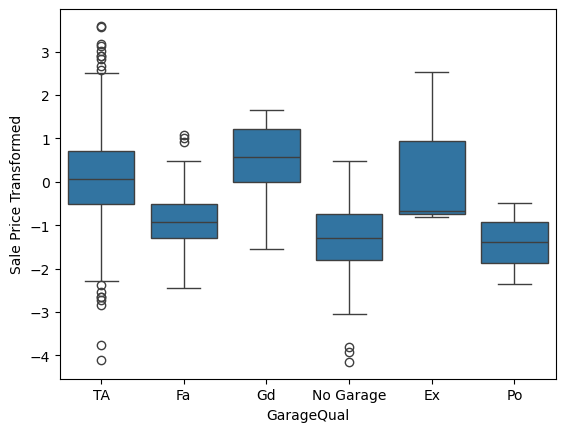

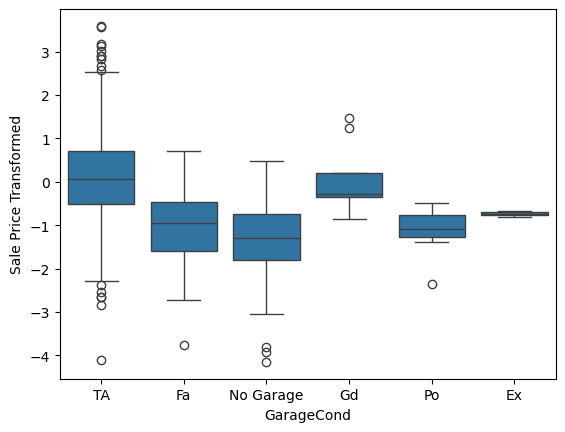

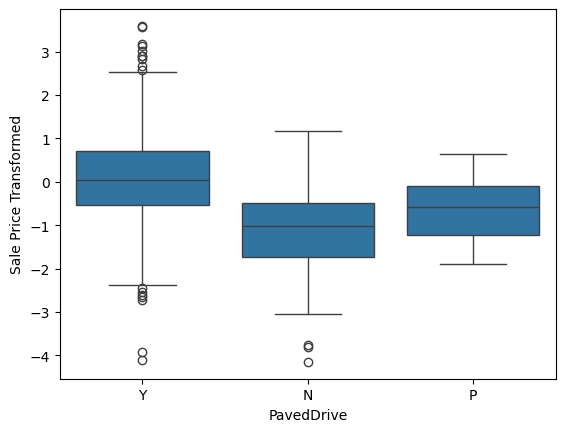

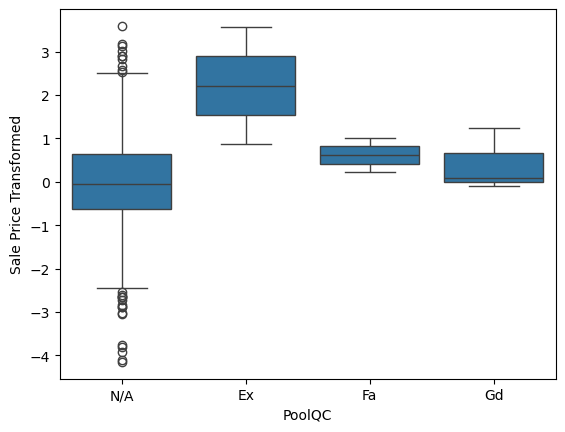

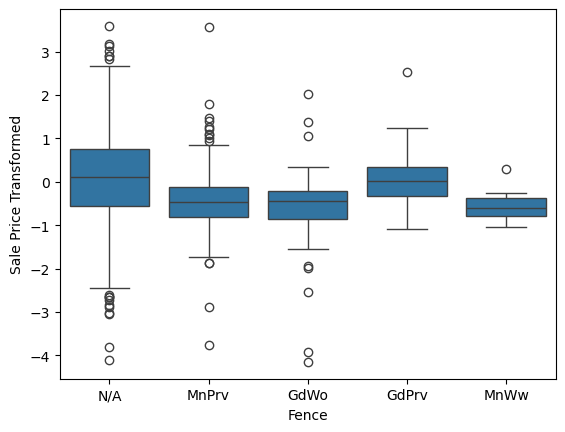

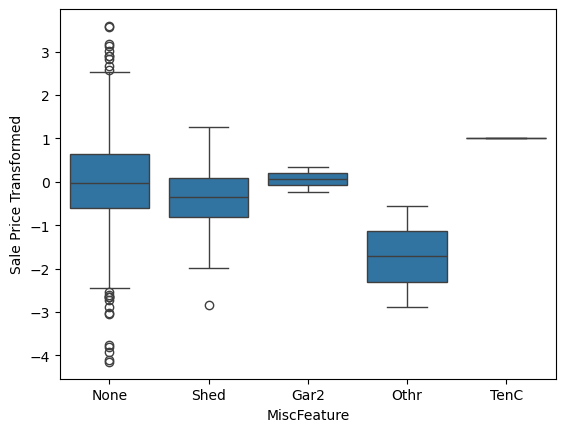

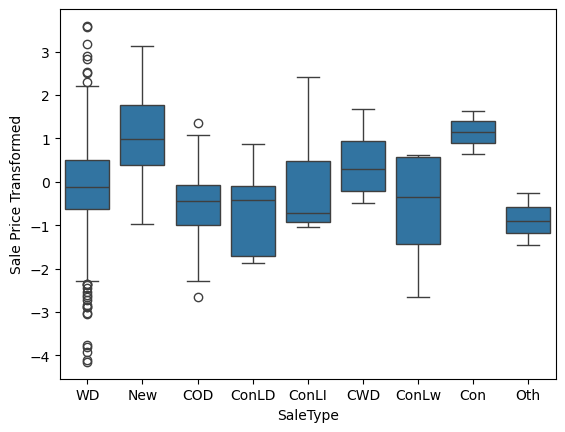

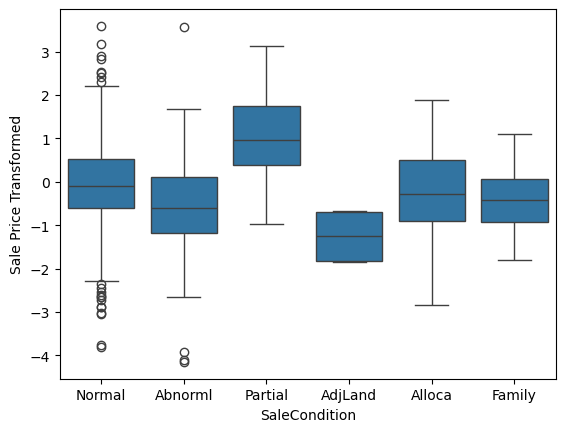

In [19]:
for X in IndexCat:
        sns.boxplot(y = HousePrice['T_SalePrice'], x = HousePrice[X])
        plt.xlabel(X)
        plt.ylabel("Sale Price Transformed")
        plt.show()

### Create Dummy/Binary Variables

In [20]:
Cats = list(HousePrice.select_dtypes(include=['object']).columns)
print(Cats)
HousePrice = pd.get_dummies(HousePrice, drop_first = True)
HousePrice[:3]

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False


In [21]:
CatsTest = list(HousePriceTest.select_dtypes(include=['object']).columns)
print(CatsTest)
HousePriceTest = pd.get_dummies(HousePriceTest, drop_first = True)
HousePriceTest[:3]

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1461,20,80.0,11622,5,6,1961,1961,0.0,468.0,...,False,False,False,False,True,False,False,False,True,False
1,1462,20,81.0,14267,6,6,1958,1958,108.0,923.0,...,False,False,False,False,True,False,False,False,True,False
2,1463,60,74.0,13830,5,5,1997,1998,0.0,791.0,...,False,False,False,False,True,False,False,False,True,False


In [22]:
HousePriceTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Columns: 242 entries, Id to SaleCondition_Partial
dtypes: bool(205), float64(11), int64(26)
memory usage: 714.0 KB


In [23]:
HousePrice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 262 entries, Id to SaleCondition_Partial
dtypes: bool(223), float64(4), int64(35)
memory usage: 762.9 KB


In [24]:
NewCats = list(HousePrice.select_dtypes(include=['bool']).columns)
NewCatsTest = list(HousePriceTest.select_dtypes(include=['bool']).columns)

NeededCats = NewCats
for element in list(NeededCats):
    if element in NewCatsTest:
        NeededCats.remove(element)
print(NeededCats)

HousePriceTest[NeededCats] = False

['Utilities_NoSeWa', 'Condition2_RRAe', 'Condition2_RRAn', 'Condition2_RRNn', 'HouseStyle_2.5Fin', 'RoofMatl_CompShg', 'RoofMatl_Membran', 'RoofMatl_Metal', 'RoofMatl_Roll', 'Exterior1st_ImStucc', 'Exterior1st_Stone', 'Exterior2nd_Other', 'Heating_GasA', 'Heating_OthW', 'Electrical_Mix', 'GarageQual_Fa', 'PoolQC_Fa', 'MiscFeature_TenC']


In [25]:
HousePriceTest[:3]

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,RoofMatl_Roll,Exterior1st_ImStucc,Exterior1st_Stone,Exterior2nd_Other,Heating_GasA,Heating_OthW,Electrical_Mix,GarageQual_Fa,PoolQC_Fa,MiscFeature_TenC
0,1461,20,80.0,11622,5,6,1961,1961,0.0,468.0,...,False,False,False,False,False,False,False,False,False,False
1,1462,20,81.0,14267,6,6,1958,1958,108.0,923.0,...,False,False,False,False,False,False,False,False,False,False
2,1463,60,74.0,13830,5,5,1997,1998,0.0,791.0,...,False,False,False,False,False,False,False,False,False,False


### Correlation

In [26]:
cor_df = HousePrice.corr().stack().reset_index()
cor_df.columns = ['Var_1', 'Var_2', 'r']
df1 = cor_df[cor_df['Var_1'] == 'SalePrice']
df2 = cor_df[cor_df['Var_1'] == 'T_SalePrice']
df1 = df1.loc[list(abs(df2['r']) > .25)]
df2 = df2.loc[abs(df2['r']) > .25]
df1.reset_index(drop=True, inplace=True)
df2.reset_index(drop=True, inplace=True)
pd.concat([df1, df2], axis = 1)



,Var_1,Var_2,r,Var_1,Var_2,r
0,SalePrice,LotArea,0.263843,T_SalePrice,LotArea,0.255397
1,SalePrice,OverallQual,0.790982,T_SalePrice,OverallQual,0.815044
2,SalePrice,YearBuilt,0.522897,T_SalePrice,YearBuilt,0.588037
3,SalePrice,YearRemodAdd,0.507101,T_SalePrice,YearRemodAdd,0.566884
4,SalePrice,MasVnrArea,0.472614,T_SalePrice,MasVnrArea,0.421401
5,SalePrice,BsmtFinSF1,0.386420,T_SalePrice,BsmtFinSF1,0.369564
6,SalePrice,TotalBsmtSF,0.613581,T_SalePrice,TotalBsmtSF,0.609149
7,SalePrice,1stFlrSF,0.605852,T_SalePrice,1stFlrSF,0.593533
8,SalePrice,2ndFlrSF,0.319334,T_SalePrice,2ndFlrSF,0.317707
9,SalePrice,GrLivArea,0.708624,T_SalePrice,GrLivArea,0.697017


In [27]:
SigVars = list(df2['Var_2'])
SigVars.remove('SalePrice')
SigVars.remove('T_SalePrice')
SigVars

['LotArea',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'FullBath',
 'HalfBath',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'MSZoning_RL',
 'MSZoning_RM',
 'LotShape_Reg',
 'Neighborhood_NoRidge',
 'Neighborhood_NridgHt',
 'HouseStyle_2Story',
 'Exterior1st_VinylSd',
 'Exterior2nd_VinylSd',
 'MasVnrType_None',
 'MasVnrType_Stone',
 'ExterQual_Gd',
 'ExterQual_TA',
 'Foundation_CBlock',
 'Foundation_PConc',
 'BsmtQual_Gd',
 'BsmtQual_TA',
 'BsmtExposure_Gd',
 'BsmtFinType1_GLQ',
 'HeatingQC_TA',
 'CentralAir_Y',
 'Electrical_SBrkr',
 'KitchenQual_Gd',
 'KitchenQual_TA',
 'FireplaceQu_Gd',
 'FireplaceQu_N/A',
 'GarageType_Attchd',
 'GarageType_Detchd',
 'GarageType_No Garage',
 'GarageFinish_No Garage',
 'GarageFinish_Unf',
 'GarageQual_No Garage',
 'GarageQual_TA',
 'GarageCond_No Garage',
 'GarageCond_TA',
 'PavedDrive_Y',
 'SaleTy

## Model 1

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(HousePrice[SigVars], HousePrice['T_SalePrice'], random_state=0, test_size=0.1)


In [29]:
Y_train

930     0.480765
656    -0.327635
45      1.608686
1348    0.646704
55      0.213866
          ...   
763     1.732586
835    -0.653835
1216   -0.997183
559     0.854183
684     0.714289
Name: T_SalePrice, Length: 1314, dtype: float64

In [30]:
X_train

,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,GarageType_No Garage,GarageFinish_No Garage,GarageFinish_Unf,GarageQual_No Garage,GarageQual_TA,GarageCond_No Garage,GarageCond_TA,PavedDrive_Y,SaleType_New,SaleCondition_Partial
930,8925,8,2007,2007,0.0,16,1466,1466,0,1466,...,False,False,False,False,True,False,True,True,False,False
656,10007,5,1959,2006,54.0,806,1053,1053,0,1053,...,False,False,False,False,True,False,True,True,False,False
45,7658,9,2005,2005,412.0,456,1752,1752,0,1752,...,False,False,False,False,True,False,True,True,False,False
1348,16196,7,1998,1998,0.0,1443,1482,1494,0,1494,...,False,False,False,False,True,False,True,True,False,False
55,10175,6,1964,1964,272.0,490,1425,1425,0,1425,...,False,False,False,False,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,9430,8,1999,1999,673.0,1163,1252,1268,1097,2365,...,False,False,False,False,True,False,True,True,False,False
835,9600,4,1950,1995,0.0,442,1067,1067,0,1067,...,False,False,True,False,True,False,True,True,False,False
1216,8930,6,1978,1978,0.0,0,0,1318,584,1902,...,False,False,True,False,True,False,True,True,False,False
559,3196,7,2003,2004,18.0,0,1374,1557,0,1557,...,False,False,False,False,True,False,True,True,False,False


In [31]:
y = Y_train
X = X_train

polyFeatures = PolynomialFeatures(degree=2, include_bias=False)
xPoly = polyFeatures.fit_transform(X)
xPoly_names = polyFeatures.get_feature_names_out(X.columns)
Xnew = pd.DataFrame(xPoly, columns = xPoly_names)
Xnew = sm.add_constant(Xnew)

xPoly = polyFeatures.fit_transform(X_test)
xPoly_names = polyFeatures.get_feature_names_out(X_test.columns)
Xnew_test = pd.DataFrame(xPoly, columns = xPoly_names)
Xnew_test = sm.add_constant(Xnew_test)

xPoly = polyFeatures.fit_transform(HousePriceTest[SigVars])
xPoly_names = polyFeatures.get_feature_names_out(HousePriceTest[SigVars].columns)
Xnew_HousePriceTest = pd.DataFrame(xPoly, columns = xPoly_names)
Xnew_HousePriceTest = sm.add_constant(Xnew_HousePriceTest)


model = sm.OLS(list(y), Xnew)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     41.98
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           3.51e-72
Time:                        23:32:51   Log-Likelihood:                 2096.0
No. Observations:                1314   AIC:                            -1802.
Df Residuals:                     119   BIC:                             4389.
Df Model:                        1194                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                          404.6397    282.484      1.432      0.155    -154.707     963.986
LotArea                                          0.0043      0.006      0.769      0.443      -0.007       0.016
OverallQual                                      3.1179     16.605      0.188      0.851     -29.762      35.997
YearBuilt                                        5.2755      3.954      1.334      0.185      -2.554      13.105
YearRemodAdd                                    -1.5341      2.020     -0.760      0.449      -5.533       2.465
MasVnrArea                                       0.3982      0.328      1.216      0.227      -0.250       1.047
BsmtFinSF1                                       0.0638      0.110      0.578      0.564      -0.155       0.282
TotalBsmtSF                                     -0.0036      0.114     -0.032      0.975      -0.229       0.222
1stFlrSF                                         0.2040      0.742      0.275      0.784      -1.265       1.673
2ndFlrSF                                         0.5332      0.770      0.692      0.490      -0.992       2.059
GrLivArea                                       -0.5371      0.784     -0.685      0.494      -2.089       1.015
FullBath                                        36.1142     36.269      0.996      0.321     -35.702     107.930
HalfBath                                        57.9509     48.904      1.185      0.238     -38.883     154.785
TotRmsAbvGrd                                    18.4026     16.414      1.121      0.264     -14.098      50.903
Fireplaces                                      17.0694    115.676      0.148      0.883    -211.980     246.119
GarageYrBlt                                     -5.1759      2.936     -1.763      0.080     -10.989       0.637
GarageCars                                     119.2059     36.516      3.265      0.001      46.901     191.510
GarageArea                                      -0.1934      0.122     -1.579      0.117      -0.436       0.049
WoodDeckSF                                       0.2358      0.234      1.009      0.315      -0.227       0.699
OpenPorchSF                                      0.1425      0.401      0.355      0.723      -0.652       0.937
MSZoning_RL                                    -78.7275    106.899     -0.736      0.463    -290.399     132.944
MSZoning_RM                                    -58.8620    100.888     -0.583      0.561    -258.629     140.905
LotShape_Reg                                     4.4809     23.769      0.189      0.851     -42.584      51.545
Neighborhood_NoRidge                           121.7869     81.249      1.499      0.137     -39.094     282.667
Neighborhood_NridgHt            

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

In [32]:
coef =  pd.DataFrame(results.summary().tables[1], columns=['Vars', 'coef', 'std err', 't', 'p', 'LB', 'UB'])
coef.drop(0, inplace=True)
coef

,Vars,coef,std err,t,p,LB,UB
1,const,404.6397,282.484,1.432,0.155,-154.707,963.986
2,LotArea,0.0043,0.006,0.769,0.443,-0.007,0.016
3,OverallQual,3.1179,16.605,0.188,0.851,-29.762,35.997
4,YearBuilt,5.2755,3.954,1.334,0.185,-2.554,13.105
5,YearRemodAdd,-1.5341,2.020,-0.760,0.449,-5.533,2.465
...,...,...,...,...,...,...,...
1649,PavedDrive_Y SaleType_New,19.4394,24.906,0.780,0.437,-29.878,68.757
1650,PavedDrive_Y SaleCondition_Partial,19.4394,24.906,0.780,0.437,-29.878,68.757
1651,SaleType_New^2,11.8135,45.624,0.259,0.796,-78.527,102.154
1652,SaleType_New SaleCondition_Partial,11.8135,45.624,0.259,0.796,-78.527,102.154


In [33]:
coef['p'] = coef['p'].astype(str)
row = coef[coef['p'] == 'nan']
remove = list(row['Vars'].astype(str))

Xnew.drop(columns = remove, inplace=True)
Xnew_test.drop(columns = remove, inplace=True)
Xnew_HousePriceTest.drop(columns = remove, inplace=True)

In [34]:
model = sm.OLS(list(y), Xnew)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     41.98
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           3.51e-72
Time:                        23:32:54   Log-Likelihood:                 2096.0
No. Observations:                1314   AIC:                            -1802.
Df Residuals:                     119   BIC:                             4389.
Df Model:                        1194                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                          404.6397    282.484      1.432      0.155    -154.707     963.986
LotArea                                          0.0043      0.006      0.769      0.443      -0.007       0.016
OverallQual                                      3.1179     16.605      0.188      0.851     -29.762      35.997
YearBuilt                                        5.2755      3.954      1.334      0.185      -2.554      13.105
YearRemodAdd                                    -1.5341      2.020     -0.760      0.449      -5.533       2.465
MasVnrArea                                       0.3982      0.328      1.216      0.227      -0.250       1.047
BsmtFinSF1                                       0.0638      0.110      0.578      0.564      -0.155       0.282
TotalBsmtSF                                     -0.0036      0.114     -0.032      0.975      -0.229       0.222
1stFlrSF                                         0.2040      0.742      0.275      0.784      -1.265       1.673
2ndFlrSF                                         0.5332      0.770      0.692      0.490      -0.992       2.059
GrLivArea                                       -0.5371      0.784     -0.685      0.494      -2.089       1.015
FullBath                                        36.1142     36.269      0.996      0.321     -35.702     107.930
HalfBath                                        57.9509     48.904      1.185      0.238     -38.883     154.785
TotRmsAbvGrd                                    18.4026     16.414      1.121      0.264     -14.098      50.903
Fireplaces                                      17.0694    115.676      0.148      0.883    -211.980     246.119
GarageYrBlt                                     -5.1759      2.936     -1.763      0.080     -10.989       0.637
GarageCars                                     119.2059     36.516      3.265      0.001      46.901     191.510
GarageArea                                      -0.1934      0.122     -1.579      0.117      -0.436       0.049
WoodDeckSF                                       0.2358      0.234      1.009      0.315      -0.227       0.699
OpenPorchSF                                      0.1425      0.401      0.355      0.723      -0.652       0.937
MSZoning_RL                                    -78.7275    106.899     -0.736      0.463    -290.399     132.944
MSZoning_RM                                    -58.8620    100.888     -0.583      0.561    -258.629     140.905
LotShape_Reg                                     4.4809     23.769      0.189      0.851     -42.584      51.545
Neighborhood_NoRidge                           121.7869     81.249      1.499      0.137     -39.094     282.667
Neighborhood_NridgHt            

In [35]:
done = 0

while done == 0:
    model = sm.OLS(list(y), Xnew)
    results = model.fit()
    coef =  pd.DataFrame(results.summary().tables[1], columns=['Vars', 'coef', 'std err', 't', 'p', 'LB', 'UB'])
    coef.drop(0, inplace=True)
    coef['p'] = coef['p'].astype(str).astype(float)
    maxP = coef['p'].max()
    row = coef[coef['p'] == maxP]
    if maxP < .05:
        done = 1
    else:
        Xnew.drop(columns = list(row['Vars'].astype(str)), inplace=True)
        Xnew_test.drop(columns = list(row['Vars'].astype(str)), inplace=True)
        Xnew_HousePriceTest.drop(columns = list(row['Vars'].astype(str)), inplace=True)


In [36]:
coef['p'] = coef['p'].astype(str)
row = coef[coef['p'] == 'nan']
remove = list(row['Vars'].astype(str))

Xnew.drop(columns = remove, inplace=True)
Xnew_test.drop(columns = remove, inplace=True)
Xnew_HousePriceTest.drop(columns = remove, inplace=True)

In [37]:
done = 0

while done == 0:
    model = sm.OLS(list(y), Xnew)
    results = model.fit()
    coef =  pd.DataFrame(results.summary().tables[1], columns=['Vars', 'coef', 'std err', 't', 'p', 'LB', 'UB'])
    coef.drop(0, inplace=True)
    coef['p'] = coef['p'].astype(str).astype(float)
    maxP = coef['p'].max()
    row = coef[coef['p'] == maxP]
    if maxP < .05:
        done = 1
    else:
        Xnew.drop(columns = list(row['Vars'].astype(str)), inplace=True)
        Xnew_test.drop(columns = list(row['Vars'].astype(str)), inplace=True)
        Xnew_HousePriceTest.drop(columns = list(row['Vars'].astype(str)), inplace=True)


In [38]:
coef['p'] = coef['p'].astype(str)
row = coef[coef['p'] == 'nan']
remove = list(row['Vars'].astype(str))

Xnew.drop(columns = remove, inplace=True)
Xnew_test.drop(columns = remove, inplace=True)
Xnew_HousePriceTest.drop(columns = remove, inplace=True)

In [39]:
model = sm.OLS(list(y), Xnew)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.945
Model:                            OLS   Adj. R-squared (uncentered):              0.934
Method:                 Least Squares   F-statistic:                              80.75
Date:                Sat, 22 Feb 2025   Prob (F-statistic):                        0.00
Time:                        23:47:32   Log-Likelihood:                          34.486
No. Observations:                1314   AIC:                                      395.0
Df Residuals:                    1082   BIC:                                      1597.
Df Model:                         232                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
LotArea                                        0.0002   2.94e-05      5.640      0.000       0.000       0.000
YearBuilt                                      0.2609      0.066      3.923      0.000       0.130       0.391
MasVnrArea                                     0.0092      0.002      4.497      0.000       0.005       0.013
1stFlrSF                                      -0.0043      0.001     -6.380      0.000      -0.006      -0.003
2ndFlrSF                                      -0.0040      0.001     -5.967      0.000      -0.005      -0.003
GrLivArea                                      0.0039      0.001      6.483      0.000       0.003       0.005
FullBath                                       0.7186      0.158      4.556      0.000       0.409       1.028
GarageYrBlt                                   -0.2465      0.066     -3.732      0.000      -0.376      -0.117
GarageCars                                     1.1568      0.159      7.293      0.000       0.846       1.468
GarageArea                                    -0.0043      0.001     -6.621      0.000      -0.006      -0.003
MasVnrType_None                                1.4379      0.255      5.631      0.000       0.937       1.939
Foundation_CBlock                             -8.7004      1.671     -5.208      0.000     -11.978      -5.422
Foundation_PConc                              -4.5563      1.695     -2.688      0.007      -7.882      -1.230
FireplaceQu_Gd                                -0.4133      0.116     -3.578      0.000      -0.640      -0.187
GarageType_Attchd                              1.2491      0.158      7.883      0.000       0.938       1.560
GarageQual_TA                                -12.4663      1.647     -7.569      0.000     -15.698      -9.235
PavedDrive_Y                                  -5.8433      1.673     -3.493      0.000      -9.126      -2.561
LotArea 1stFlrSF                            2.686e-07   5.31e-08      5.062      0.000    1.64e-07    3.73e-07
LotArea 2ndFlrSF                            2.653e-07   5.31e-08      4.997      0.000    1.61e-07    3.69e-07
LotArea GrLivArea                          -2.739e-07   5.29e-08     -5.177      0.000   -3.78e-07    -1.7e-07
LotArea MSZoning_RL                        -2.676e-05   7.99e-06     -3.349      0.001   -4.24e-05   -1.11e-05
LotArea Foundation_CBlock                  -2.491e-05   7.78e-06     -3.202      0.001   -4.02e-05   -9.64e-06
LotArea Foundation_PConc                   -2.539e-05   7.63e-06     -3.326      0.001   -4.04e-05   -1.04e-05
LotArea BsmtExposure_Gd                    -8.146e-06   3.33e-06     -2.446      0.015   -1.47e-05

### Training Residuals 

MSE 0.05555582574844594


1278

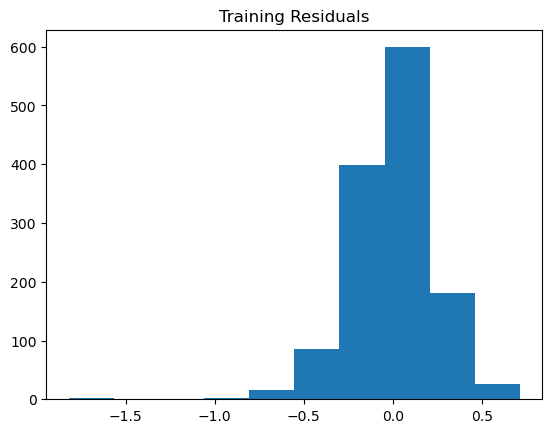

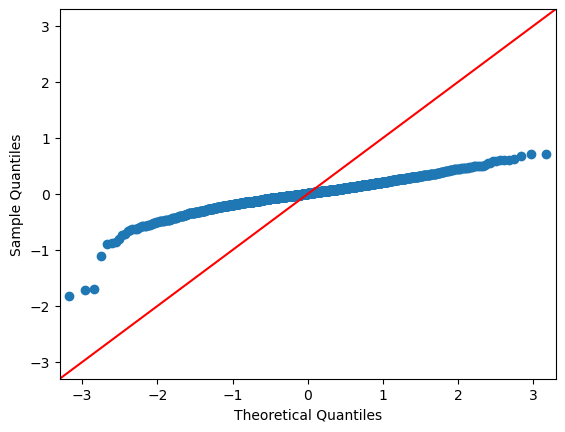

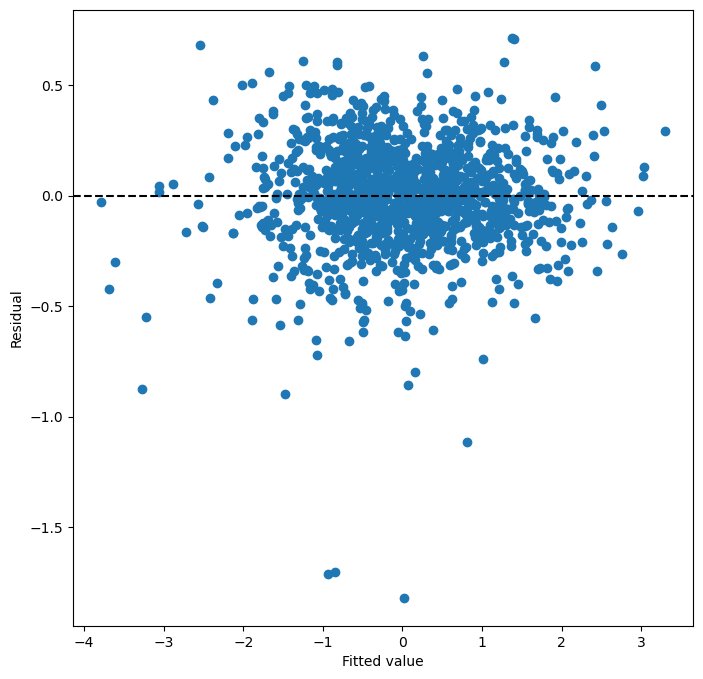

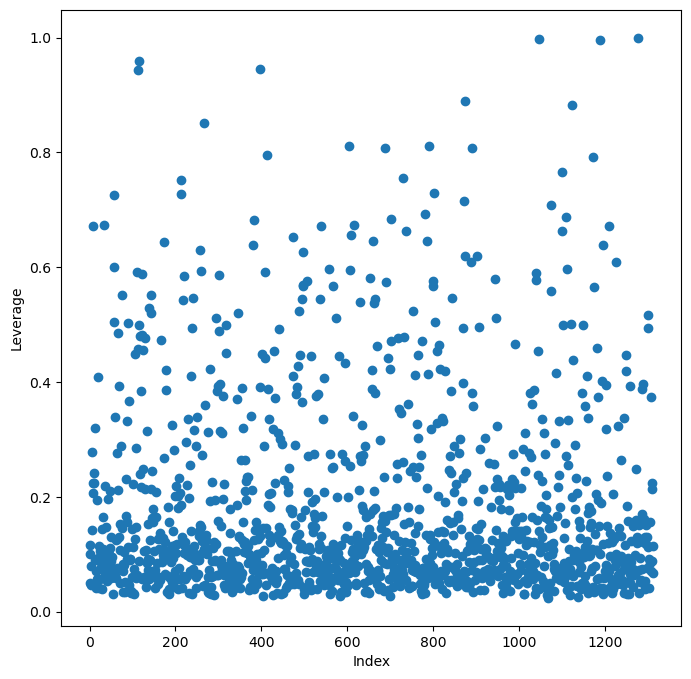

In [40]:
Y_pred = results.predict(Xnew)
resid = list(y) - Y_pred
#print(resid)
#print(y)
#print(Y_pred)
plt.hist(resid)
plt.title('Training Residuals')
sm.qqplot(resid, line ='45') 
print('MSE',np.mean(resid**2))

ax = subplots(figsize=(8,8))[1]
ax.scatter(Y_pred, resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(Xnew.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

### Testing Residuals 

0     -0.843250
1     -0.383494
2     -0.022254
3     -0.171784
4     -0.326330
         ...   
141    0.151785
142    0.221134
143    0.198283
144   -2.045566
145    0.052024
Length: 146, dtype: float64
0      1.319388
1     -0.172462
2     -1.021530
3      0.539163
4     -1.299957
         ...   
141   -0.488140
142    0.448322
143   -0.440446
144    0.977164
145   -0.053515
Length: 146, dtype: float64
MSE 7.478928415713089


1278

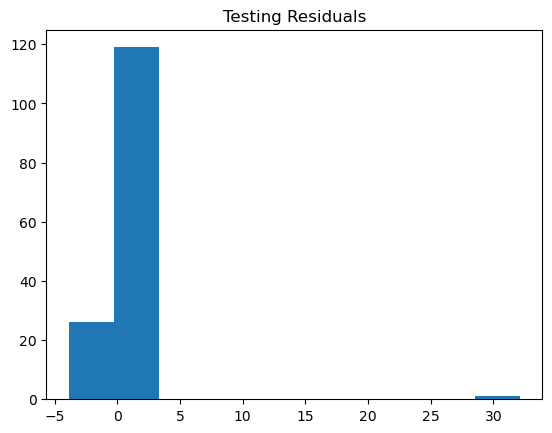

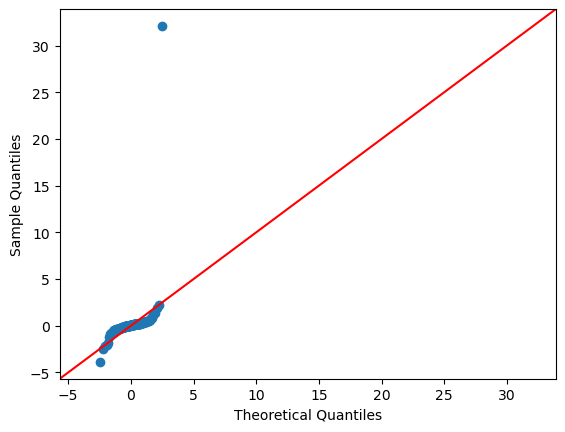

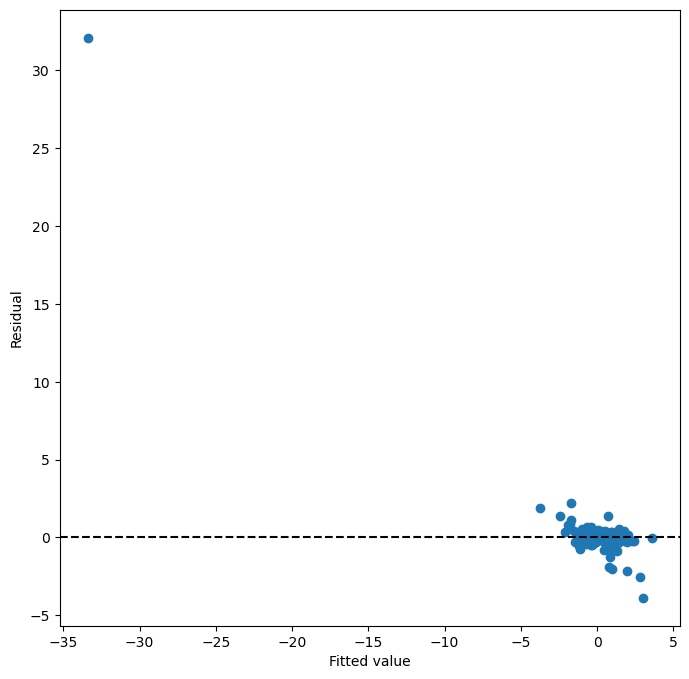

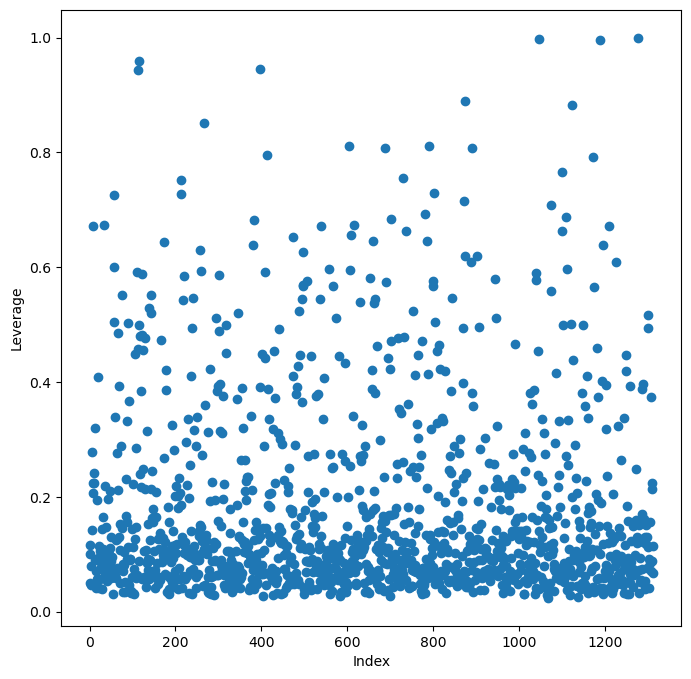

In [41]:
Y_pred = results.predict(Xnew_test)
resid = list(Y_test) - Y_pred
print(resid)
print(Y_pred)
plt.hist(resid)
plt.title('Testing Residuals')

sm.qqplot(resid, line ='45') 
print('MSE',np.mean(resid**2))

ax = subplots(figsize=(8,8))[1]
ax.scatter(Y_pred, resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(Xnew.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

### Export Predictions

In [42]:
SalePrice = results.predict(Xnew_HousePriceTest)
print(Xnew_HousePriceTest.isnull().sum().sum())

SalePrice = pt.inverse_transform(np.array(SalePrice).reshape(-1, 1))
print(SalePrice)


output = pd.DataFrame(HousePriceTest['Id'])
output['SalePrice'] = SalePrice
print(output['SalePrice'].min())
print(output)
output.to_csv('model_Reg_2nd_linear.csv', index = False)

0
[[ 88956.98653402]
 [151995.81444799]
 [198778.89142802]
 ...
 [175960.90550376]
 [103558.78239352]
 [205195.34643801]]
24.670320922467546
        Id      SalePrice
0     1461   88956.986534
1     1462  151995.814448
2     1463  198778.891428
3     1464  186874.398280
4     1465  182557.188236
...    ...            ...
1454  2915   83002.715380
1455  2916   83834.079888
1456  2917  175960.905504
1457  2918  103558.782394
1458  2919  205195.346438

[1459 rows x 2 columns]


## Lasso Regression

In [43]:
X = np.asarray(Xnew)
Y = y

K = 10
kfold = skm.KFold(K,
                  random_state=0,
                  shuffle=True)
scaler = StandardScaler(with_mean=True,  with_std=True)


lassoCV = skl.ElasticNetCV(n_alphas=100, 
                           l1_ratio=1,
                           cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler),
                         ('lasso', lassoCV)])
pipeCV.fit(X, Y)
tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

C:\Users\charl\.conda\envs\ISLP\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.15868018661757333, tolerance: 0.12448443208275459
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\charl\.conda\envs\ISLP\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.15466678354789565, tolerance: 0.12448443208275459
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\charl\.conda\envs\ISLP\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.15141081099486087, tolerance: 0.12448443208275459
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\charl\.conda\envs\ISLP\Lib\site-packages\sklearn\lin

0.001474901384601139

C:\Users\charl\.conda\envs\ISLP\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.3651347755137522, tolerance: 0.1336899730163189
  model = cd_fast.enet_coordinate_descent_gram(


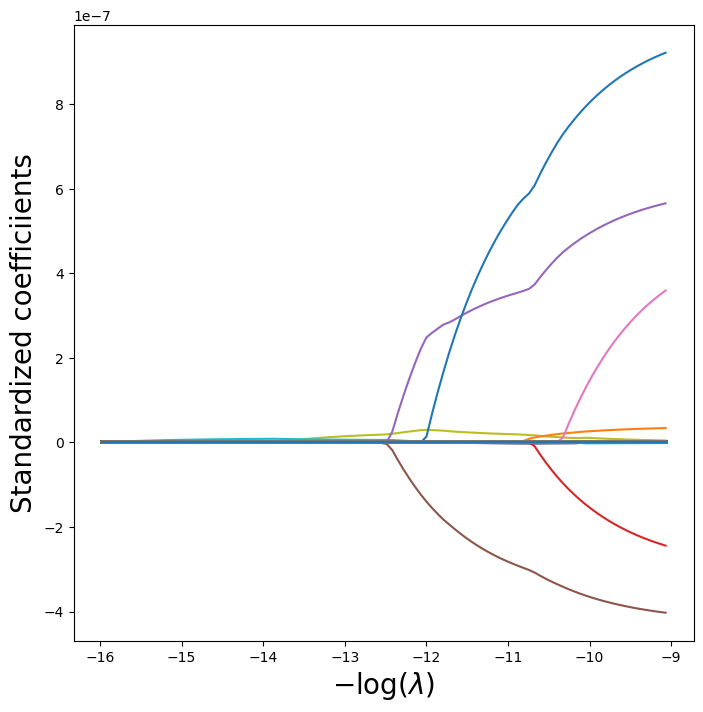

In [44]:
lambdas, soln_array = skl.Lasso.path(X, 
                                    Y,
                                    l1_ratio=1,
                                    n_alphas=100)[:2]
soln_path = pd.DataFrame(soln_array.T,
                         columns=Xnew.columns,
                         index=-np.log(lambdas))

path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
#ax.legend(loc='none')
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficiients', fontsize=20);

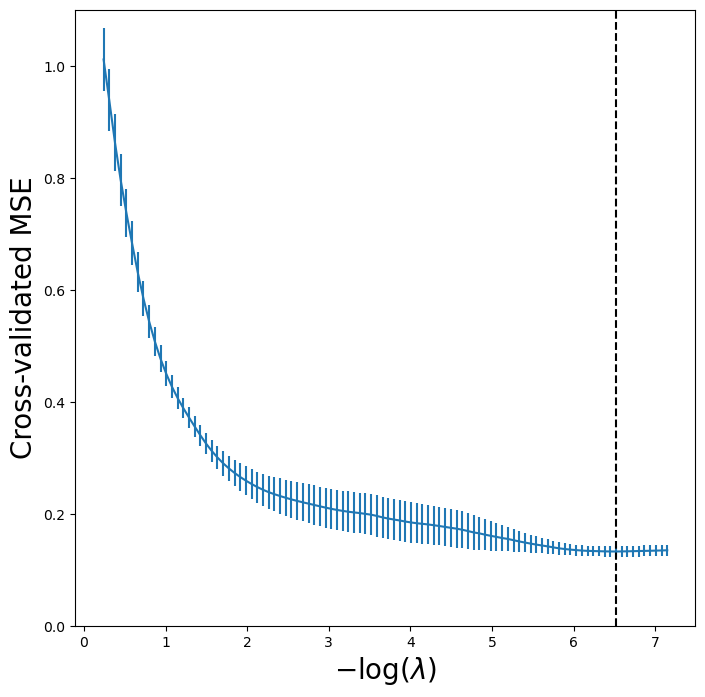

In [45]:
lassoCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls='--')
ax.set_ylim([0,1.1])
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

In [46]:
print('MSE: ', np.min(tuned_lasso.mse_path_.mean(1)))
print('R2: ', 1-np.min(tuned_lasso.mse_path_.mean(1))/np.var(Y))

MSE:  0.132528368666535
R2:  0.8697417033124923


In [47]:
Vars = Xnew.columns[np.where(tuned_lasso.coef_ != 0)]
X_lasso = MS(list(Vars)).fit_transform(Xnew)
Xtest_lasso = MS(list(Vars)).fit_transform(Xnew_test)
X_HousePriceTest_lasso = MS(list(Vars)).fit_transform(Xnew_HousePriceTest)



model_lasso = sm.OLS(list(Y), X_lasso)
results_lasso = model_lasso.fit()
results_lasso.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     91.53
Date:                Sat, 22 Feb 2025   Prob (F-statistic):               0.00
Time:                        23:47:42   Log-Likelihood:                -233.08
No. Observations:                1314   AIC:                             754.2
Df Residuals:                    1170   BIC:                             1500.
Df Model:                         143                                         
Covariance Type:            nonrobust                                         
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
intercept                                     -6.8774      1.650     -4.168      0.000     -10.115      -3.640
LotArea                                     2.532e-05   7.15e-06      3.541      0.000    1.13e-05    3.94e-05
YearBuilt                                      0.0014      0.001      1.619      0.106      -0.000       0.003
MasVnrArea                                     0.0001   7.93e-05      1.501      0.134   -3.66e-05       0.000
1stFlrSF                                       0.0015      0.000      5.195      0.000       0.001       0.002
2ndFlrSF                                       0.0004      0.000      1.664      0.096   -7.43e-05       0.001
GrLivArea                                      0.0006      0.000      2.653      0.008       0.000       0.001
FullBath                                       0.0770      0.100      0.769      0.442      -0.120       0.274
Foundation_PConc                              -2.1826      3.195     -0.683      0.495      -8.451       4.086
GarageType_Attchd                              0.6574      0.225      2.928      0.003       0.217       1.098
PavedDrive_Y                                  -0.0089      0.053     -0.166      0.868      -0.113       0.096
LotArea 1stFlrSF                            -1.57e-09   3.52e-09     -0.446      0.656   -8.48e-09    5.34e-09
LotArea GrLivArea                           -6.55e-09   3.42e-09     -1.915      0.056   -1.33e-08    1.59e-10
LotArea Foundation_CBlock                   1.852e-06   4.14e-06      0.448      0.654   -6.26e-06    9.97e-06
LotArea BsmtExposure_Gd                     -7.24e-06   3.68e-06     -1.970      0.049   -1.45e-05   -3.01e-08
OverallQual HalfBath                           0.0560      0.017      3.355      0.001       0.023       0.089
OverallQual Fireplaces                         0.0807      0.016      4.912      0.000       0.048       0.113
OverallQual GarageArea                      4.111e-05    3.3e-05      1.246      0.213   -2.36e-05       0.000
OverallQual FireplaceQu_N/A                    0.1331      0.020      6.531      0.000       0.093       0.173
YearBuilt TotRmsAbvGrd                      7.154e-06   6.87e-06      1.041      0.298   -6.32e-06    2.06e-05
YearBuilt GarageYrBlt                       1.004e-07   8.72e-08      1.151      0.250   -7.07e-08    2.71e-07
YearBuilt WoodDeckSF                        1.718e-07   2.49e-07      0.690      0.491   -3.17e-07    6.61e-07
YearBuilt Neighborhood_NoRidge                -0.0001      0.000     -0.721      0.471      -0.001       0.000
YearBuilt BsmtQual_TA                         -0.0001   8.15e-05     -1.540      0.124      -0.000    3.44e-05
YearBuilt BsmtFinType1_GLQ                  6.659e-05   4.03e-05      1.651      0.099

### Training Residuals

MSE 0.08348238178511651


1278

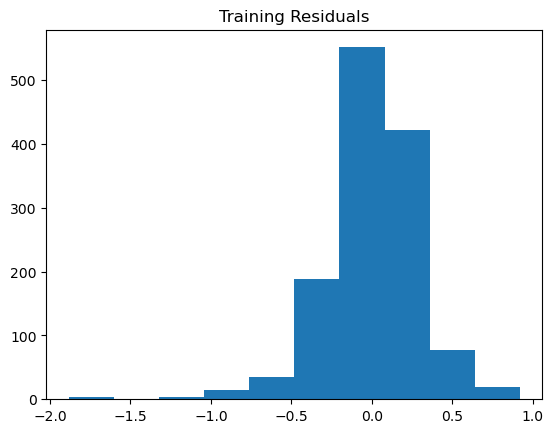

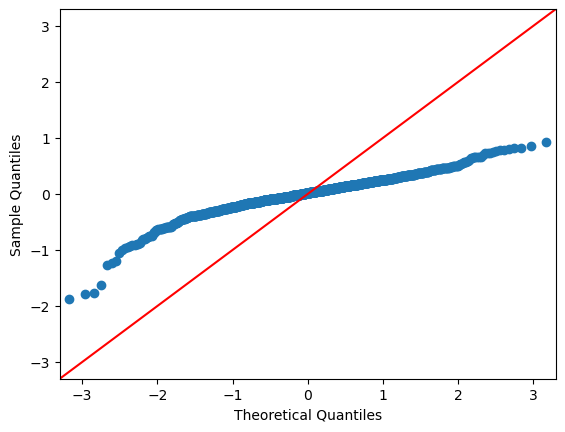

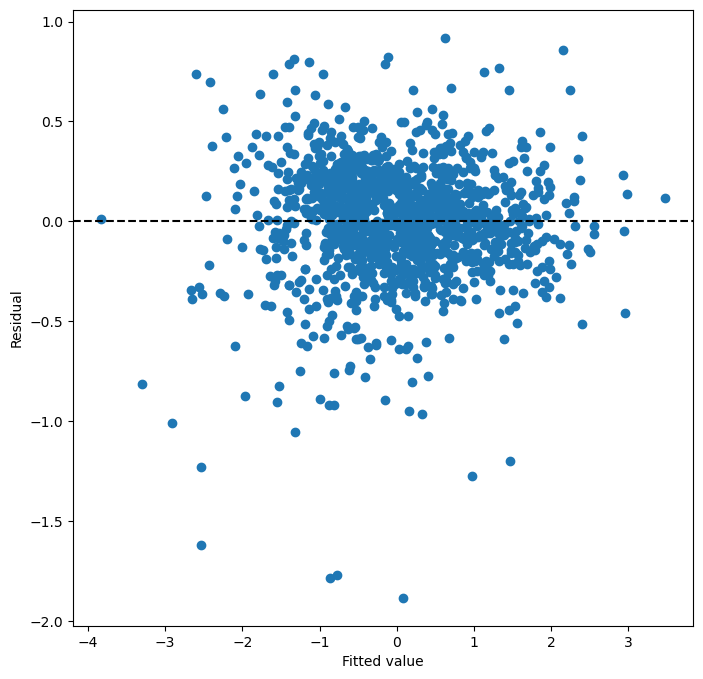

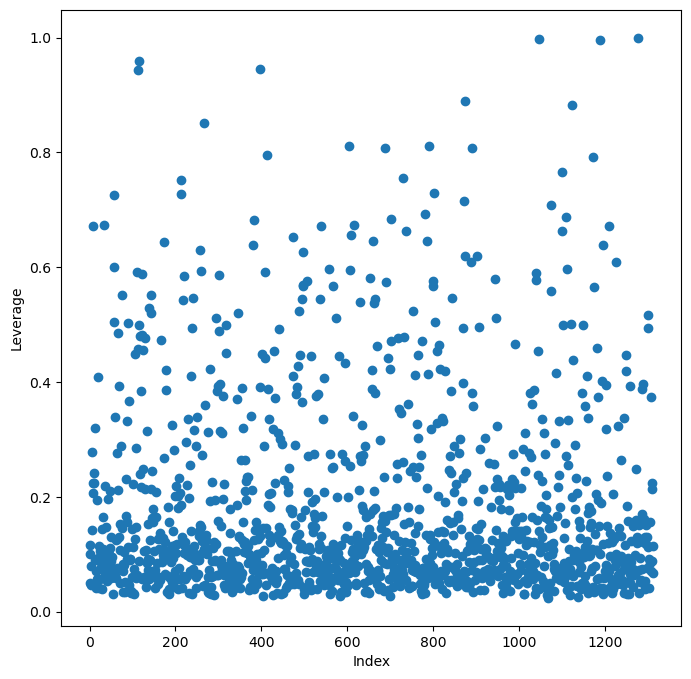

In [48]:
Y_pred = results_lasso.predict(X_lasso)
resid = list(Y) - Y_pred
plt.hist(resid)
plt.title('Training Residuals')

sm.qqplot(resid, line ='45') 
print('MSE',np.mean(resid**2))

ax = subplots(figsize=(8,8))[1]
ax.scatter(Y_pred, resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

### Testing Residuals

MSE 0.10675000497400021


1278

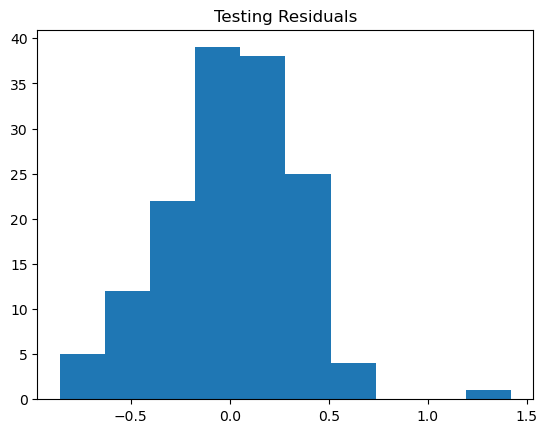

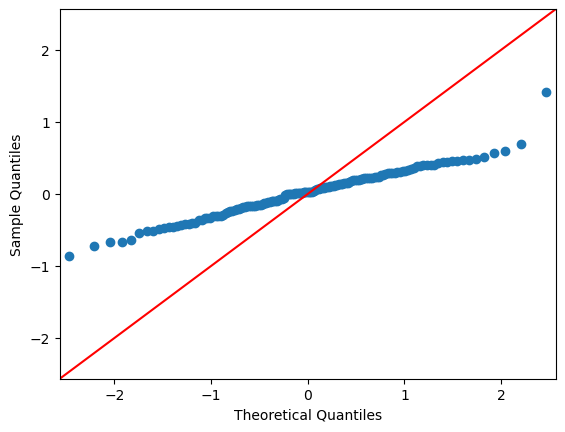

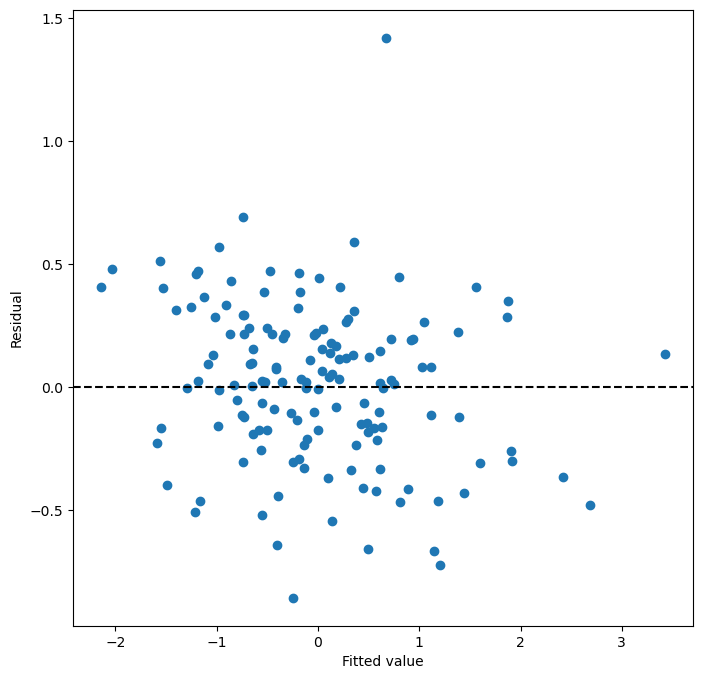

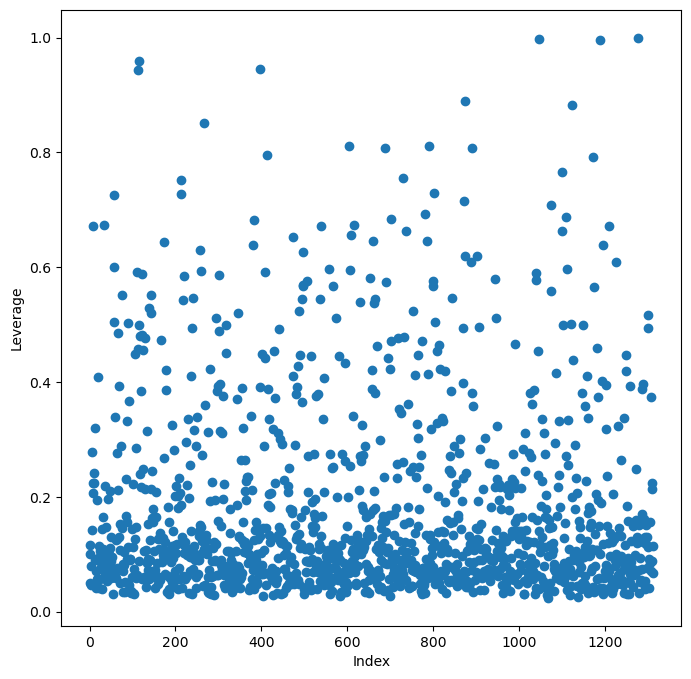

In [49]:
Y_pred = results_lasso.predict(Xtest_lasso)
resid = list(Y_test) - Y_pred
plt.hist(resid)
plt.title('Testing Residuals')

sm.qqplot(resid, line ='45') 
print('MSE',np.mean(resid**2))

ax = subplots(figsize=(8,8))[1]
ax.scatter(Y_pred, resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

## Model 3

In [50]:
Xnew2 = Xnew[Vars]
Xnew2 = sm.add_constant(Xnew2)

Xnew_test = Xnew_test[Vars]
Xnew_test = sm.add_constant(Xnew_test)

Xnew_HousePriceTest = Xnew_HousePriceTest[Vars]
Xnew_HousePriceTest = sm.add_constant(Xnew_HousePriceTest)


In [51]:
done = 0

while done == 0:
    model3 = sm.OLS(list(y), Xnew2)
    results3 = model3.fit()
    coef =  pd.DataFrame(results3.summary().tables[1], columns=['Vars', 'coef', 'std err', 't', 'p', 'LB', 'UB'])
    coef.drop(0, inplace=True)
    coef['p'] = coef['p'].astype(str).astype(float)
    maxP = coef['p'].max()
    row = coef[coef['p'] == maxP]
    if maxP < .05:
        done = 1
    else:
        Xnew2.drop(columns = list(row['Vars'].astype(str)), inplace=True)
        Xnew_test.drop(columns = list(row['Vars'].astype(str)), inplace=True)
        Xnew_HousePriceTest.drop(columns = list(row['Vars'].astype(str)), inplace=True)


In [52]:
results3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     160.1
Date:                Sat, 22 Feb 2025   Prob (F-statistic):               0.00
Time:                        23:47:45   Log-Likelihood:                -269.56
No. Observations:                1314   AIC:                             703.1
Df Residuals:                    1232   BIC:                             1128.
Df Model:                          81                                         
Covariance Type:            nonrobust                                         
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const                                         -8.3967      1.370     -6.130      0.000     -11.084      -5.709
LotArea                                     2.377e-05   5.18e-06      4.588      0.000    1.36e-05    3.39e-05
YearBuilt                                      0.0022      0.001      3.208      0.001       0.001       0.004
1stFlrSF                                       0.0013      0.000      5.376      0.000       0.001       0.002
2ndFlrSF                                       0.0005      0.000      2.379      0.017    9.38e-05       0.001
GrLivArea                                      0.0007      0.000      3.760      0.000       0.000       0.001
GarageType_Attchd                              0.7244      0.153      4.724      0.000       0.424       1.025
LotArea GrLivArea                          -6.934e-09   2.64e-09     -2.630      0.009   -1.21e-08   -1.76e-09
LotArea BsmtExposure_Gd                    -5.665e-06   2.62e-06     -2.158      0.031   -1.08e-05   -5.15e-07
OverallQual HalfBath                           0.0510      0.014      3.768      0.000       0.024       0.078
OverallQual Fireplaces                         0.0996      0.012      8.446      0.000       0.076       0.123
OverallQual FireplaceQu_N/A                    0.1674      0.015     11.052      0.000       0.138       0.197
YearBuilt GarageYrBlt                       1.001e-07   3.11e-08      3.217      0.001    3.91e-08    1.61e-07
YearBuilt WoodDeckSF                         1.01e-07   3.81e-08      2.651      0.008    2.63e-08    1.76e-07
YearBuilt BsmtQual_TA                         -0.0001   3.84e-05     -2.916      0.004      -0.000   -3.67e-05
YearBuilt HeatingQC_TA                        -0.0003   4.86e-05     -6.864      0.000      -0.000      -0.000
YearBuilt FireplaceQu_N/A                     -0.0003   5.85e-05     -4.322      0.000      -0.000      -0.000
YearRemodAdd Exterior2nd_VinylSd               0.0001   3.69e-05      3.259      0.001    4.79e-05       0.000
YearRemodAdd BsmtExposure_Gd                8.877e-05   2.38e-05      3.732      0.000    4.21e-05       0.000
YearRemodAdd GarageQual_TA                     0.0001   5.52e-05      2.316      0.021    1.96e-05       0.000
YearRemodAdd GarageCond_TA                     0.0004   5.68e-05      6.915      0.000       0.000       0.001
BsmtFinSF1 MasVnrType_None                  7.304e-05   3.13e-05      2.331      0.020    1.16e-05       0.000
BsmtFinSF1 CentralAir_Y                        0.0002   3.21e-05      5.786      0.000       0.000       0.000
TotalBsmtSF GarageYrBlt                     6.443e-08   2.32e-08      2.775      0.006    1.89e-08     1.1e-07
TotalBsmtSF GarageType_No Garage               0.0002   5.79e-05      4.128      0.000

### Training Residuals

MSE 0.08824958432597295


1278

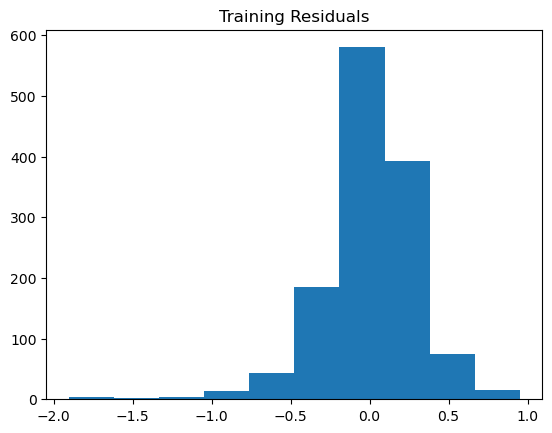

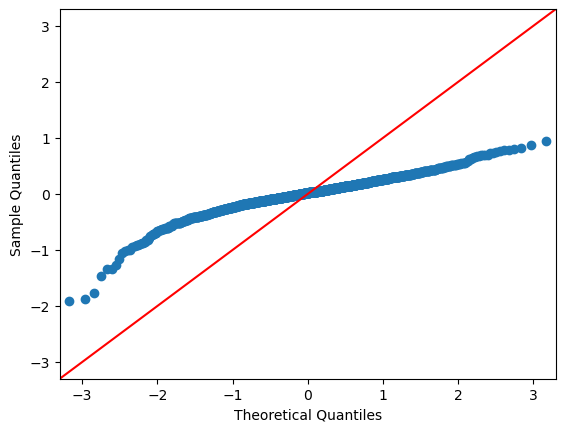

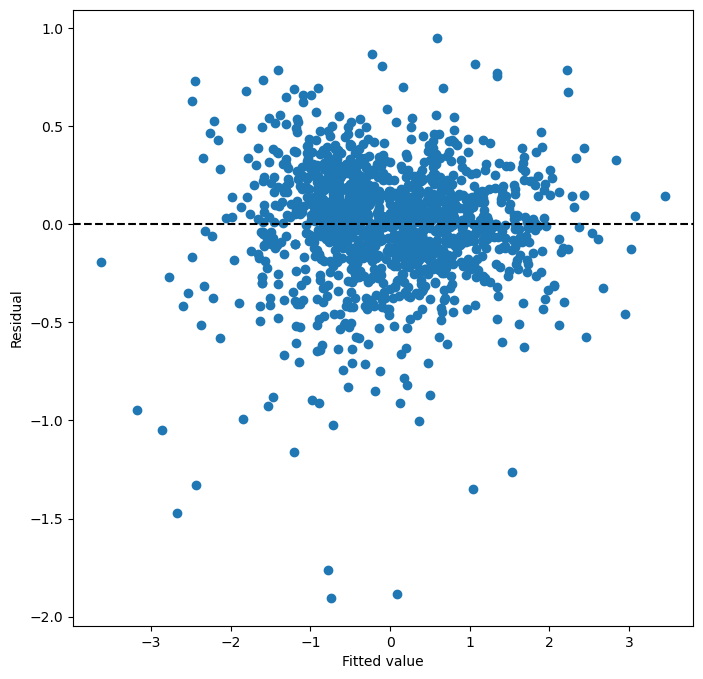

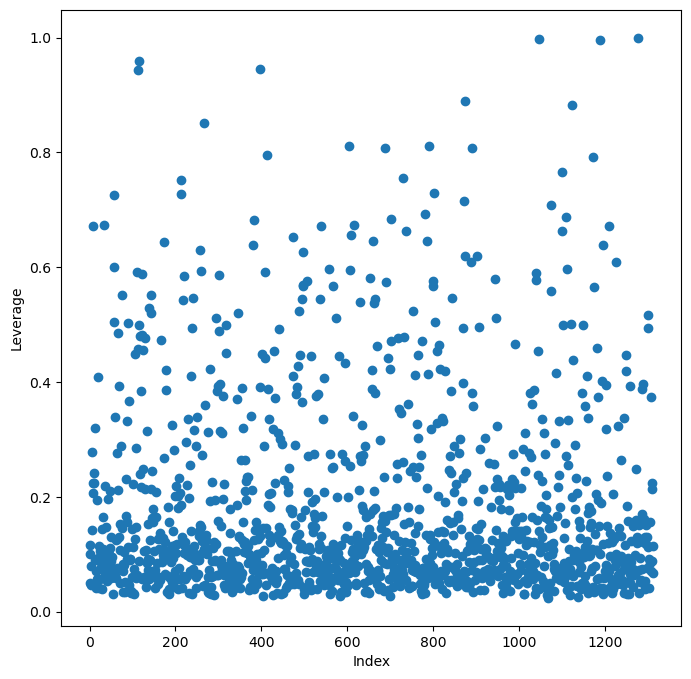

In [53]:
Y_pred = results3.predict(Xnew2)
resid = list(y) - Y_pred
plt.hist(resid)
plt.title('Training Residuals')

sm.qqplot(resid, line ='45') 
print('MSE',np.mean(resid**2))

ax = subplots(figsize=(8,8))[1]
ax.scatter(Y_pred, resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

### Testing Residuals

MSE 0.10859686135294046


1278

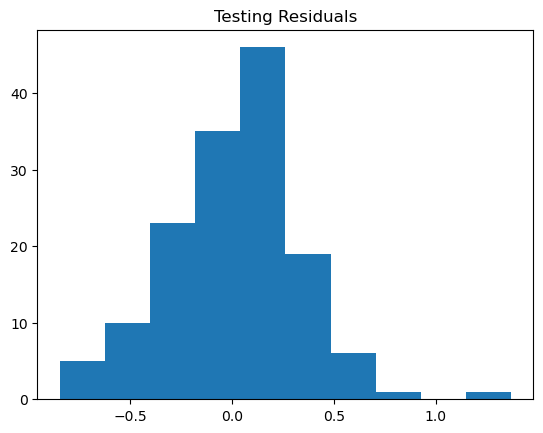

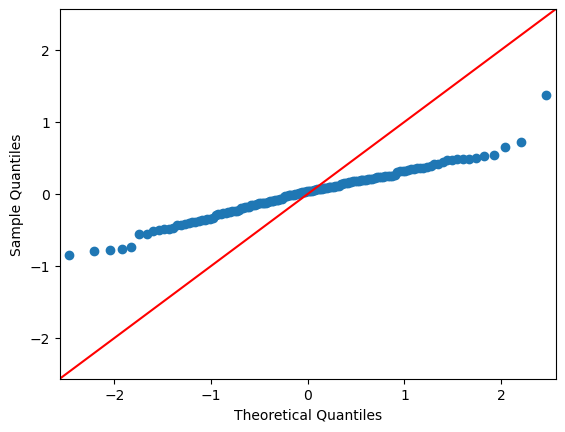

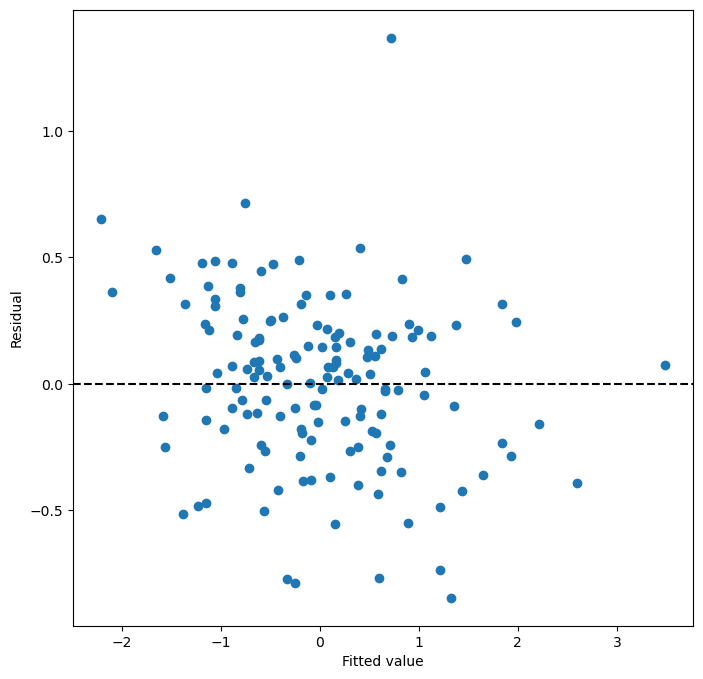

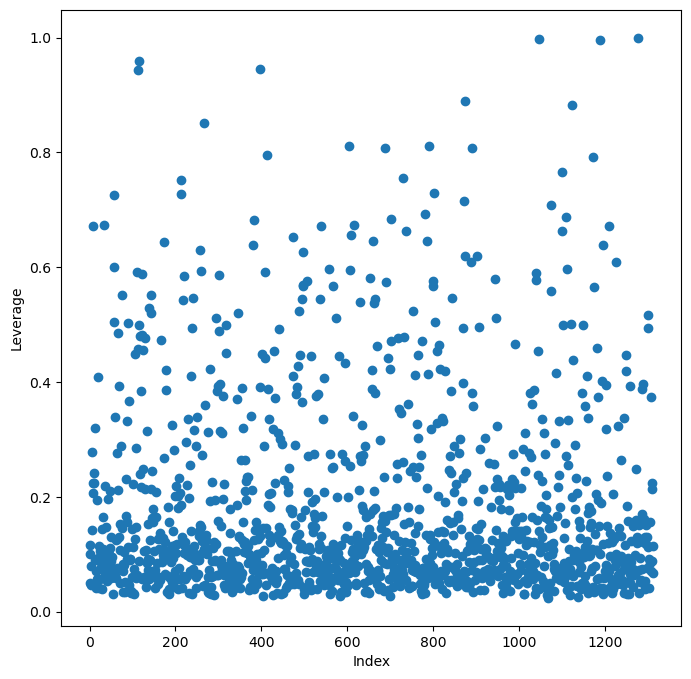

In [54]:
Y_pred = results3.predict(Xnew_test)
resid = list(Y_test) - Y_pred
#print(resid)
#print(Y_pred)
plt.hist(resid)
plt.title('Testing Residuals')

sm.qqplot(resid, line ='45') 
print('MSE',np.mean(resid**2))

ax = subplots(figsize=(8,8))[1]
ax.scatter(Y_pred, resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(Xnew.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

### Export Predictions

In [55]:
SalePrice = results3.predict(Xnew_HousePriceTest)
print(Xnew_HousePriceTest.isnull().sum().sum())

SalePrice = pt.inverse_transform(np.array(SalePrice).reshape(-1, 1))
print(SalePrice)


output = pd.DataFrame(HousePriceTest['Id'])
output['SalePrice'] = SalePrice
print(output['SalePrice'].min())
print(output)
print(output.isnull().sum().sum())
output.to_csv('model_Lasso_Reg_2nd_Degree.csv', index = False)

0
[[ 88868.32117641]
 [165870.11003754]
 [184282.92405123]
 ...
 [172668.55926505]
 [119738.51986849]
 [221832.94771082]]
45693.597871781865
        Id      SalePrice
0     1461   88868.321176
1     1462  165870.110038
2     1463  184282.924051
3     1464  187789.175308
4     1465  181030.410247
...    ...            ...
1454  2915   73458.734751
1455  2916   85574.177704
1456  2917  172668.559265
1457  2918  119738.519868
1458  2919  221832.947711

[1459 rows x 2 columns]
0


## PCA

In [56]:
scaler = StandardScaler(with_std=True,
                        with_mean=True)
Xnew2_scaled = scaler.fit_transform(Xnew2)
Xnew2_scaled

array([[ 0.        , -0.1604738 ,  1.18740314, ...,  0.83526907,
        -0.52627743, -0.7824768 ],
       [ 0.        , -0.05665142, -0.39319479, ...,  0.83526907,
        -0.52627743, -0.7824768 ],
       [ 0.        , -0.28204769,  1.1215449 , ...,  0.83526907,
        -0.52627743, -0.7824768 ],
       ...,
       [ 0.        , -0.15999403,  0.23245856, ...,  0.83526907,
        -0.52627743,  1.27799317],
       [ 0.        , -0.71019504,  1.05568665, ...,  0.83526907,
        -0.52627743, -0.7824768 ],
       [ 0.        ,  0.5922864 ,  0.89104103, ...,  0.83526907,
        -0.52627743, -0.7824768 ]])

In [57]:
Xnew_test_scaled = scaler.fit_transform(Xnew_test)
Xnew_test_scaled

array([[ 0.        ,  5.46949378, -0.60620523, ...,  0.82350526,
        -0.57207755, -0.84714052],
       [ 0.        , -0.07212647, -1.16971316, ...,  0.82350526,
        -0.57207755,  1.18044171],
       [ 0.        , -0.66387339, -0.85273995, ..., -1.21432132,
         1.74801475,  1.18044171],
       ...,
       [ 0.        , -0.23709834,  0.09817968, ..., -1.21432132,
         1.74801475,  1.18044171],
       [ 0.        ,  0.74316928, -0.18357429, ..., -1.21432132,
        -0.57207755,  1.18044171],
       [ 0.        , -0.50368332,  0.6616876 , ...,  0.82350526,
        -0.57207755, -0.84714052]])

In [58]:
pcaHouses = PCA()
pcaHouses.fit(Xnew2_scaled)

PCA()

In [59]:
%%capture
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ticks = np.arange(pcaHouses.n_components_)+1
ax = axes[0]
ax.plot(ticks,
        pcaHouses.explained_variance_ratio_,
        marker='o')
ax.set_xlabel('Principal Component');
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0,1])
ax.set_xticks(ticks)

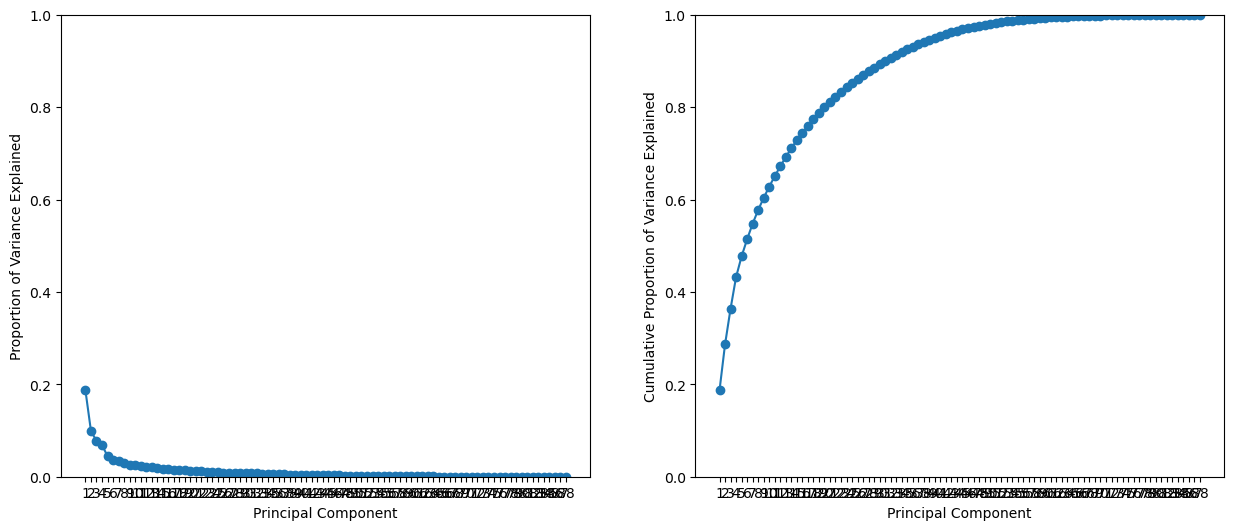

In [60]:
ax = axes[1]
ax.plot(ticks,
        pcaHouses.explained_variance_ratio_.cumsum(),
        marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
fig

In [61]:
pcaHouses.explained_variance_ratio_.cumsum()

array([0.18698181, 0.28628212, 0.36363318, 0.43221339, 0.47701836,
       0.51402003, 0.54765769, 0.57738951, 0.60336231, 0.62791004,
       0.65029766, 0.67170542, 0.69178962, 0.71082863, 0.72852793,
       0.74423641, 0.75888758, 0.77332   , 0.78720415, 0.79977676,
       0.81132744, 0.82263886, 0.83336827, 0.84322159, 0.85253967,
       0.86123501, 0.86963478, 0.87770873, 0.88536346, 0.89272321,
       0.89978685, 0.90683194, 0.91362915, 0.919748  , 0.92570272,
       0.93107944, 0.93614577, 0.9409392 , 0.9456901 , 0.95033969,
       0.95443346, 0.95825009, 0.96182672, 0.96518614, 0.9680933 ,
       0.97088059, 0.97364936, 0.97599455, 0.97817055, 0.98028971,
       0.98231447, 0.98405264, 0.9856797 , 0.98709362, 0.98843453,
       0.98958614, 0.99064691, 0.99164556, 0.9925402 , 0.99336405,
       0.99407559, 0.99474799, 0.99536589, 0.99592881, 0.99635575,
       0.99675501, 0.99712009, 0.9974678 , 0.99778429, 0.99809857,
       0.9983984 , 0.99866045, 0.99889308, 0.99910918, 0.99931

In [62]:
pcaHouses80 = PCA(n_components=20)

In [63]:
pcaHousesReduced = pcaHouses80.fit_transform(Xnew2_scaled)

In [64]:
pcaXnew_test = pcaHouses80.fit_transform(Xnew_test_scaled)

## Model 4

In [65]:
pcaHousesReduced = sm.add_constant(pcaHousesReduced)
pcaHousesReduced = pd.DataFrame(pcaHousesReduced, columns=['Const', 'x1', 'x2','x3','x4','x5','x6','x7','x8','x9','x10','x11','x12','x13','x14','x15','x16','x17','x18','x19','x20'])
pcaHousesReduced

,Const,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20
0,1.0,3.281527,2.464833,-1.687769,-4.424561,0.039710,1.894737,-1.474119,0.207418,-0.445346,...,-0.005784,-0.690895,0.287086,-0.671691,1.422957,-0.200509,0.387054,-0.187071,-0.801504,-0.080405
1,1.0,-1.090621,0.004986,-0.239315,-2.175447,-0.637984,0.041999,-1.314767,-1.775228,0.868315,...,2.706147,-1.324812,-3.027300,-1.573875,-0.489242,2.275339,1.549592,-0.346232,0.232647,0.745261
2,1.0,3.070657,-0.601137,1.648125,-1.423063,2.362459,-0.279617,1.784022,1.114745,-1.200973,...,-1.697420,-0.084903,0.331246,-0.009799,-1.059737,0.705243,0.977977,-0.630430,0.078136,-0.626929
3,1.0,5.016429,0.592492,1.687462,-2.799233,1.445287,0.183233,-2.901905,-1.484855,0.841097,...,-0.379883,1.221444,-0.002885,-1.173308,0.273286,-0.603382,-1.449823,0.315942,2.176432,1.838937
4,1.0,-0.964222,-3.079464,2.760695,-0.855864,0.076084,-1.202034,0.032344,1.183260,0.311672,...,-0.607189,-1.008661,-0.157058,-1.753395,1.006644,0.562727,1.037255,-0.004780,-0.482545,-0.245953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1309,1.0,7.929425,2.062085,-1.066749,2.113166,-1.743231,-0.886299,0.816256,-0.620399,-0.208449,...,0.263092,1.211065,-1.213869,0.051237,-0.169808,-3.466172,-2.750061,-0.549866,0.084013,-1.637210
1310,1.0,-1.573874,-1.692345,0.475803,-3.325688,-2.412101,0.525795,-0.458995,0.352584,-0.426108,...,0.215327,0.564632,0.965029,1.231362,-0.273959,-0.253483,-0.904001,0.999712,-1.589426,-0.129534
1311,1.0,-2.097175,-0.581849,-3.011797,0.788982,1.383816,1.338504,-2.118279,5.062063,-1.959405,...,1.146092,-0.277879,0.877856,1.423437,1.120454,-0.431776,-1.732434,-0.476303,-0.993863,1.173674
1312,1.0,4.372890,0.999174,0.299190,-2.660788,0.808045,-1.000134,-0.663960,-0.263322,-0.663891,...,-1.406117,0.227175,-0.255840,0.807389,0.211211,-0.705603,0.558987,0.032468,-0.676800,-0.310893


In [66]:
pcaXnew_test = sm.add_constant(pcaXnew_test)
pcaXnew_test = pd.DataFrame(pcaXnew_test, columns=['Const', 'x1', 'x2','x3','x4','x5','x6','x7','x8','x9','x10','x11','x12','x13','x14','x15','x16','x17','x18','x19','x20'])
pcaXnew_test

,Const,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20
0,1.0,5.993561,-1.400276,9.329742,-2.296707,4.572862,-5.202414,0.262486,-2.734924,-0.718194,...,0.853593,-4.124032,-1.879957,0.426414,6.385196,1.864006,1.331282,-1.434980,-0.162006,-3.019370
1,1.0,-1.470344,-2.133694,4.485116,1.652129,0.330991,2.465632,-0.541365,-0.615010,1.379531,...,-0.294461,0.035016,-1.229310,-0.671682,-0.431858,0.395917,-1.596598,1.650397,-0.883681,0.476296
2,1.0,-3.534071,-1.803935,1.454508,1.324660,1.053794,0.331036,-3.208429,0.199810,0.298781,...,-1.365595,1.925695,-0.669596,1.276713,0.116296,0.614056,-0.805438,1.350150,-0.366888,-0.622152
3,1.0,1.458946,-1.361134,3.232776,1.716514,-3.199993,1.557545,1.819403,2.077409,0.296594,...,1.805954,0.367633,-0.179800,0.857233,-1.044617,-1.149753,1.764726,-1.944815,0.907494,0.917281
4,1.0,-5.894630,-1.558391,-3.203185,5.559932,1.255987,-2.084691,0.257207,-1.027600,-0.412803,...,0.775211,2.789334,-0.052758,-0.541663,-0.593214,-0.380447,2.881200,-1.406573,1.043499,1.510556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,1.0,-1.838481,0.036018,-4.312309,-1.424090,0.649552,-1.016967,2.756511,1.803322,-0.198998,...,1.448344,-0.733702,-0.481099,0.077449,-0.807828,0.924342,-0.365081,-0.572492,-1.997616,0.290948
142,1.0,2.495529,-1.813854,5.851589,-1.366823,2.430588,-1.366128,-1.917121,1.876619,2.035967,...,3.567953,2.013296,-1.687322,0.723922,1.071651,-1.994545,0.070870,0.430066,-1.141358,-1.892571
143,1.0,-3.213450,-1.292169,-0.500562,-1.560656,-1.309543,-1.729386,-2.584825,0.143348,0.214364,...,-0.100643,2.419960,-1.463555,1.237801,0.811097,-0.446750,-0.355754,-0.648129,0.215862,-1.112477
144,1.0,-3.115347,-0.379800,0.669541,-0.361232,-2.556515,-0.868862,0.106740,-1.484991,0.288234,...,0.820025,1.461046,-1.305286,-1.743679,2.010278,0.729194,-1.026257,-4.007694,-0.404408,0.413762


In [67]:
pcaHousesReduced.columns

Index(['Const', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20'],
      dtype='object')

In [68]:
done = 0

while done == 0:
    model4 = sm.OLS(list(y), pcaHousesReduced)
    results4 = model4.fit()
    coef =  pd.DataFrame(results4.summary().tables[1], columns=['Vars', 'coef', 'std err', 't', 'p', 'LB', 'UB'])
    coef.drop(0, inplace=True)
    coef['p'] = coef['p'].astype(str).astype(float)
    maxP = coef['p'].max()
    row = coef[coef['p'] == maxP]
    if maxP < .05:
        done = 1
    else:
        pcaHousesReduced.drop(columns = list(row['Vars'].astype(str)), inplace=True)
        pcaXnew_test.drop(columns = list(row['Vars'].astype(str)), inplace=True)


In [69]:
results4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.763
Model:                            OLS   Adj. R-squared (uncentered):              0.761
Method:                 Least Squares   F-statistic:                              380.9
Date:                Sat, 22 Feb 2025   Prob (F-statistic):                        0.00
Time:                        23:47:49   Log-Likelihood:                         -930.53
No. Observations:                1314   AIC:                                      1883.
Df Residuals:                    1303   BIC:                                      1940.
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.2078      0.003     61.596      0.000       0.201       0.214
x2            -0.0275      0.005     -5.932      0.000      -0.037      -0.018
x3             0.0584      0.005     11.125      0.000       0.048       0.069
x4             0.0328      0.006      5.880      0.000       0.022       0.044
x6             0.0589      0.008      7.761      0.000       0.044       0.074
x7             0.0384      0.008      4.828      0.000       0.023       0.054
x10           -0.0472      0.009     -5.068      0.000      -0.065      -0.029
x12            0.0722      0.010      7.235      0.000       0.053       0.092
x14           -0.0583      0.011     -5.510      0.000      -0.079      -0.038
x17            0.0240      0.012      1.991      0.047       0.000       0.048
x20            0.0332      0.013      2.552      0.011       0.008       0.059
==============================================================================
Omnibus:                     1029.524   Durbin-Watson:                   2.026
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            61912.469
Skew:                          -3.107   Prob(JB):                         0.00
Kurtosis:                      36.048   Cond. No.                         3.86
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Training Residuals

MSE 0.24134226864869124


1278

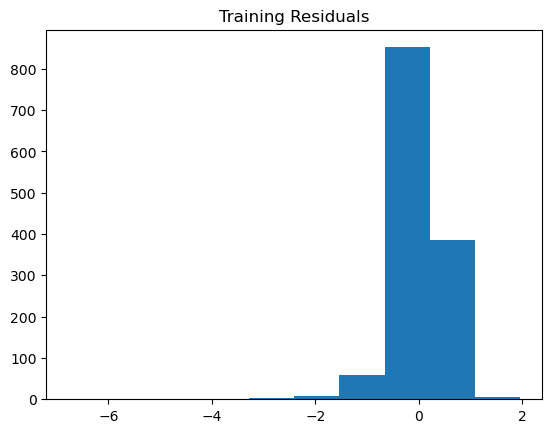

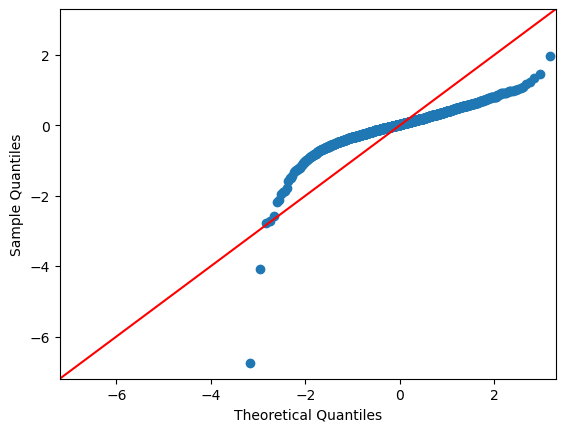

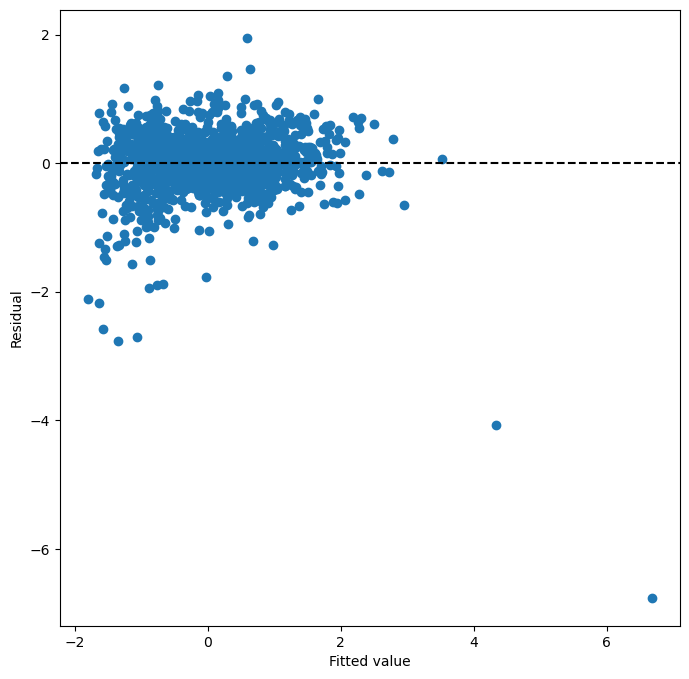

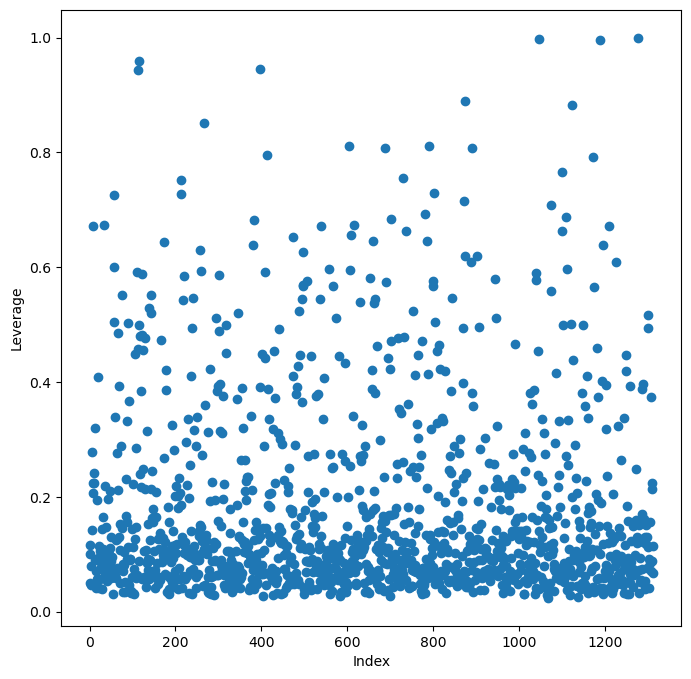

In [70]:
Y_pred = results4.predict(pcaHousesReduced)
resid = list(y) - Y_pred
plt.hist(resid)
plt.title('Training Residuals')

sm.qqplot(resid, line ='45') 
print('MSE',np.mean(resid**2))

ax = subplots(figsize=(8,8))[1]
ax.scatter(Y_pred, resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

### Testing Residuals

MSE 0.24435786207211505


1278

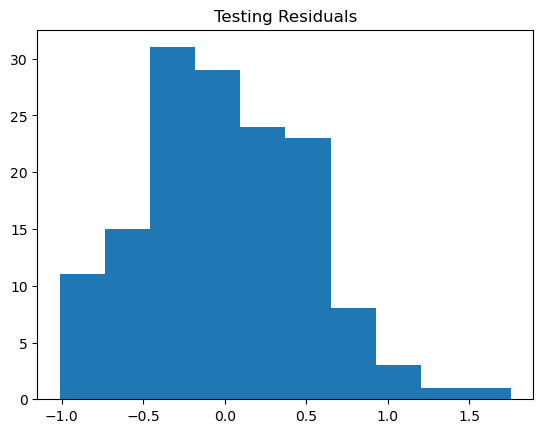

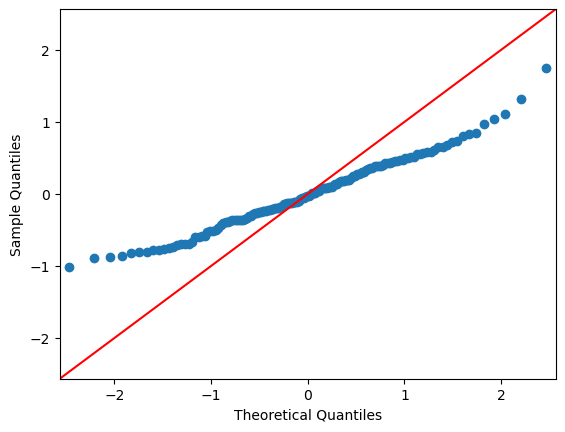

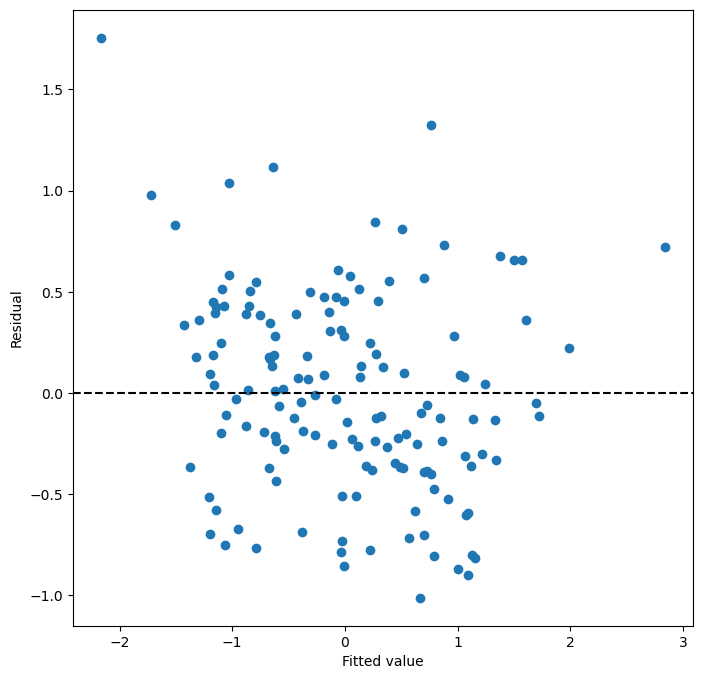

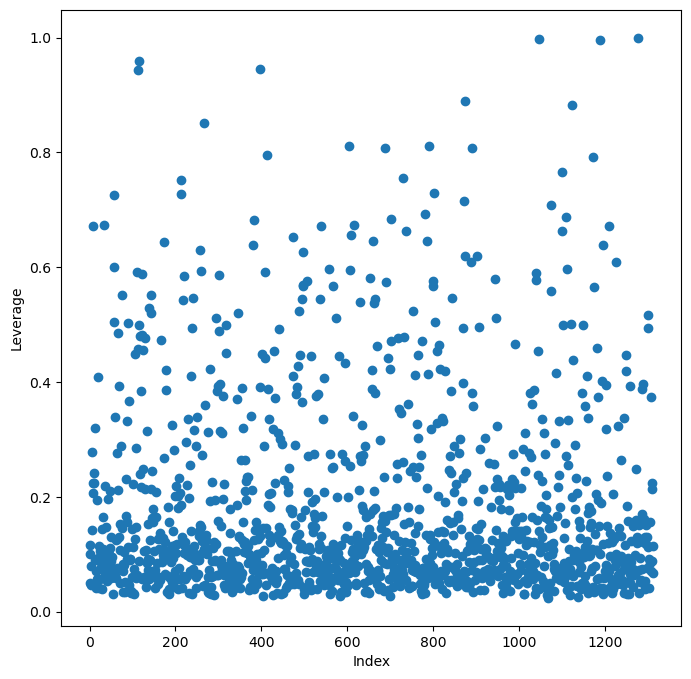

In [71]:
Y_pred = results4.predict(pcaXnew_test)
resid = list(Y_test) - Y_pred
plt.hist(resid)
plt.title('Testing Residuals')

sm.qqplot(resid, line ='45') 
print('MSE',np.mean(resid**2))

ax = subplots(figsize=(8,8))[1]
ax.scatter(Y_pred, resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)